## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
import warnings, os

warnings.filterwarnings("ignore")
os.makedirs("plots", exist_ok=True)

## Global Styling

In [5]:
# GLOBAL STYLE
# ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
C = dict(blue="#378ADD", teal="#1D9E75", coral="#D85A30",
         purple="#7F77DD", amber="#BA7517", gray="#888780",
         green="#5BA832")
FIGSIZE = (14, 5)

def savefig(name, tight=True):
    if tight: plt.tight_layout()
    plt.savefig(f"plots/{name}.png", dpi=150, bbox_inches="tight")
    plt.show(); print(f"  → plots/{name}.png")

def section(title, n):
    bar = "═" * 60
    print(f"\n{bar}\n  SECTION {n}: {title}\n{bar}")

## Load Dataset

In [7]:
section("LOAD RAW DATA", 1)

df_raw = pd.read_csv(r"C:\Users\Shipra\OneDrive\Documents\GitHub\B2B-Invoice-payment-behaviour-segmentation-late-payment-predictor\project3\Dataset.csv", engine="python")
df_raw.columns = df_raw.columns.str.strip()

# Column reference
CUST      = "Cust_Num"
AMT       = "Amount"
DELAY     = "Days_Overdue_Delay"
PAY_TERM  = "Payment_Term"
AGE_MON   = "Age_Of_Customer_Months"
AGE_YR    = "Age_Of_Customer_Year"
N_ORDERS  = "No_of_orders_by_customer"
RANK_ORD  = "Rank_of_order_by_customer"
QTR       = "Quarter_clearing"
WD_CLEAR  = "Weekday_clearnum"
WD_DUE    = "Weekday_due.1"
TARGET    = "DelayFlag"

DATE_COLS  = ["Doc_Date","Net_Due_Date","Posting_Date","Clearing_date"]
NUM_COLS   = [AMT, DELAY, PAY_TERM, AGE_MON, AGE_YR, N_ORDERS, RANK_ORD, QTR]
CAT_COLS   = ["Payment_Method_description","Region","Weekday_clearing","Weekday_due"]

print(f"Shape          : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns        : {df_raw.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df_raw.head().to_string())
print(f"\nData types:\n{df_raw.dtypes.to_string()}")


════════════════════════════════════════════════════════════
  SECTION 1: LOAD RAW DATA
════════════════════════════════════════════════════════════
Shape          : 45,839 rows × 29 columns
Columns        : ['Cust_Num', 'Payment_Method_description', 'Document_No', 'Amount', 'Amount_Bins', 'Clearing_doc', 'Zipcode', 'Region', 'City', 'Customer_Name', 'Age_Of_Customer_Months', 'Age_Of_Customer_Year', 'Customer_Age_Year_Bins', 'Payment_Term', 'Payment_Term_Bins', 'Days_Overdue_Delay', 'Delay_Bins', 'Doc_Date', 'Net_Due_Date', 'Posting_Date', 'Clearing_date', 'No_of_orders_by_customer', 'Rank_of_order_by_customer', 'Weekday_clearing', 'Weekday_due', 'Quarter_clearing', 'DelayFlag', 'Weekday_clearnum', 'Weekday_due.1']

First 5 rows:
     Cust_Num Payment_Method_description  Document_No  Amount  Amount_Bins  Clearing_doc Zipcode Region  City Customer_Name  Age_Of_Customer_Months  Age_Of_Customer_Year Customer_Age_Year_Bins  Payment_Term Payment_Term_Bins  Days_Overdue_Delay Delay_Bins    

## EDA- RAW DATA QUALITY

In [8]:

section("EDA — RAW DATA QUALITY", 2)


print("\n──  Basic quality metrics ──")
n_rows, n_cols  = df_raw.shape
n_missing       = df_raw.isnull().sum().sum()
n_duplicates    = df_raw.duplicated().sum()
n_neg_amt       = (df_raw[AMT] < 0).sum()

print(f"  Total rows         : {n_rows:,}")
print(f"  Total columns      : {n_cols}")
print(f"  Total missing vals : {n_missing:,}")
print(f"  Duplicate rows     : {n_duplicates:,}")
print(f"  Negative amounts   : {n_neg_amt:,}")


════════════════════════════════════════════════════════════
  SECTION 2: EDA — RAW DATA QUALITY
════════════════════════════════════════════════════════════

──  Basic quality metrics ──
  Total rows         : 45,839
  Total columns      : 29
  Total missing vals : 0
  Duplicate rows     : 0
  Negative amounts   : 0


In [9]:
# ── 2.2 Missing values per column ────────────────────────────
print("\n── 2.2 Missing values per column ──")
missing_df = pd.DataFrame({
    "Missing Count": df_raw.isnull().sum(),
    "Missing %":     (df_raw.isnull().mean() * 100).round(2),
    "Dtype":         df_raw.dtypes
})
print(missing_df.to_string())


── 2.2 Missing values per column ──
                            Missing Count  Missing %    Dtype
Cust_Num                                0        0.0    int64
Payment_Method_description              0        0.0      str
Document_No                             0        0.0    int64
Amount                                  0        0.0    int64
Amount_Bins                             0        0.0      str
Clearing_doc                            0        0.0    int64
Zipcode                                 0        0.0      str
Region                                  0        0.0      str
City                                    0        0.0      str
Customer_Name                           0        0.0      str
Age_Of_Customer_Months                  0        0.0  float64
Age_Of_Customer_Year                    0        0.0  float64
Customer_Age_Year_Bins                  0        0.0      str
Payment_Term                            0        0.0    int64
Payment_Term_Bins                

## Numeric Descriptive Statistics

In [10]:

print("\n──  Numeric descriptive statistics ──")
print(df_raw[NUM_COLS].describe().round(2).to_string())



──  Numeric descriptive statistics ──
           Amount  Days_Overdue_Delay  Payment_Term  Age_Of_Customer_Months  Age_Of_Customer_Year  No_of_orders_by_customer  Rank_of_order_by_customer  Quarter_clearing
count    45839.00            45839.00      45839.00                45839.00              45839.00                  45839.00                   45839.00          45839.00
mean     17807.16                0.97         13.79                  150.59                 11.66                   7066.47                    3533.74              2.56
std      68777.03               14.19         26.35                   21.11                  1.66                   3346.32                    2809.62              1.15
min          2.00             -117.00          0.00                    0.50                  0.00                      1.00                       1.00              1.00
25%        785.00               -1.00          5.00                  155.00                 12.00                   

## Target class distribution

In [11]:

print("\n──  Target (DelayFlag) distribution ──")
vc = df_raw[TARGET].value_counts()
print(vc)
print(f"  Late payment rate: {vc.get(1,0)/len(df_raw)*100:.1f}%")


──  Target (DelayFlag) distribution ──
DelayFlag
1    30096
0    15743
Name: count, dtype: int64
  Late payment rate: 65.7%


## Categorical Value Counts

In [12]:

print("\n── Categorical columns ──")
for col in CAT_COLS:
    print(f"\n  {col} ({df_raw[col].nunique()} unique):")
    print(df_raw[col].value_counts().head(5).to_string())


── Categorical columns ──

  Payment_Method_description (8 unique):
Payment_Method_description
Direct Debits 2      24010
Direct Debits 1      18981
No Payment Method     1308
Regulatory             771
Regulatory 2           604

  Region (30 unique):
Region
AA125    10219
AA113     9712
AA121     8054
AA127     6367
AA120     3983

  Weekday_clearing (7 unique):
Weekday_clearing
Tue    19381
Mon    17207
Fri     3545
Sat     2790
Wed     2005

  Weekday_due (7 unique):
Weekday_due
Sat    10809
Mon     9194
Sun     8909
Wed     7619
Tue     7595


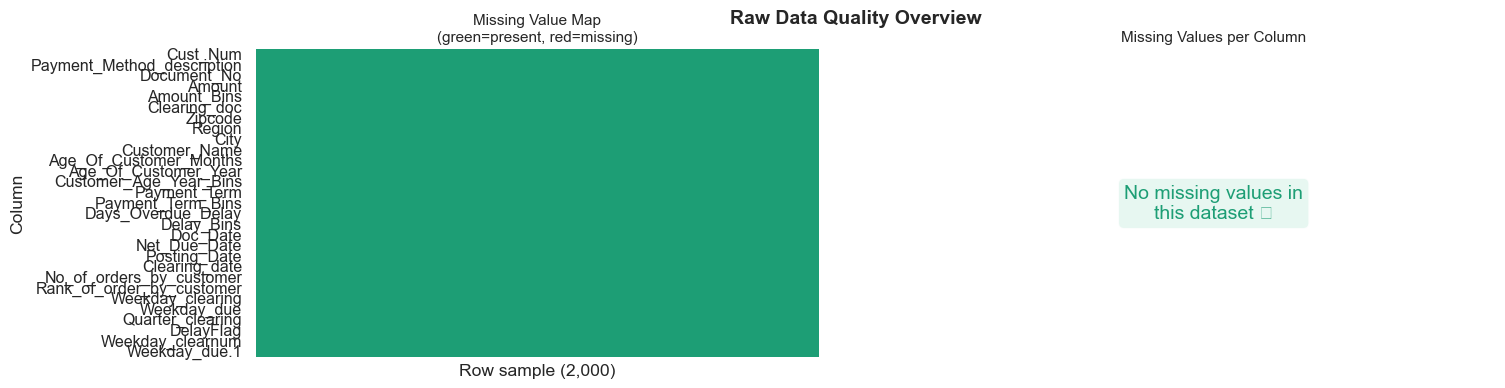

In [13]:
# PLOT 01 — Missing Value Heatmap (BEFORE)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("Raw Data Quality Overview", fontsize=14, fontweight="bold")

# Missing heatmap (sample 2000 rows for visibility)
sample_mask = df_raw.sample(min(2000, len(df_raw)), random_state=42).isnull().T
sns.heatmap(sample_mask.astype(int), cmap=[C["teal"], C["coral"]],
            cbar=False, ax=axes[0], yticklabels=df_raw.columns,
            xticklabels=False)
axes[0].set_title("Missing Value Map\n(green=present, red=missing)", fontsize=11)
axes[0].set_ylabel("Column"); axes[0].set_xlabel("Row sample (2,000)")

# Missing count bar
miss_col = df_raw.isnull().sum()
miss_col = miss_col[miss_col > 0]
if len(miss_col):
    axes[1].bar(miss_col.index, miss_col.values, color=C["coral"], edgecolor="white")
    axes[1].set_title("Missing Count per Column", fontsize=11)
    axes[1].set_ylabel("Count"); axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].text(0.5, 0.5, "No missing values in\nthis dataset ✓",
                 ha="center", va="center", fontsize=14, color=C["teal"],
                 transform=axes[1].transAxes,
                 bbox=dict(boxstyle="round", facecolor="#E1F5EE", alpha=0.8))
    axes[1].set_title("Missing Values per Column", fontsize=11)
    axes[1].axis("off")

## PLOT 02 — Target Distribution

Text(0.5, 1.0, 'Proportion (Pie Chart)')

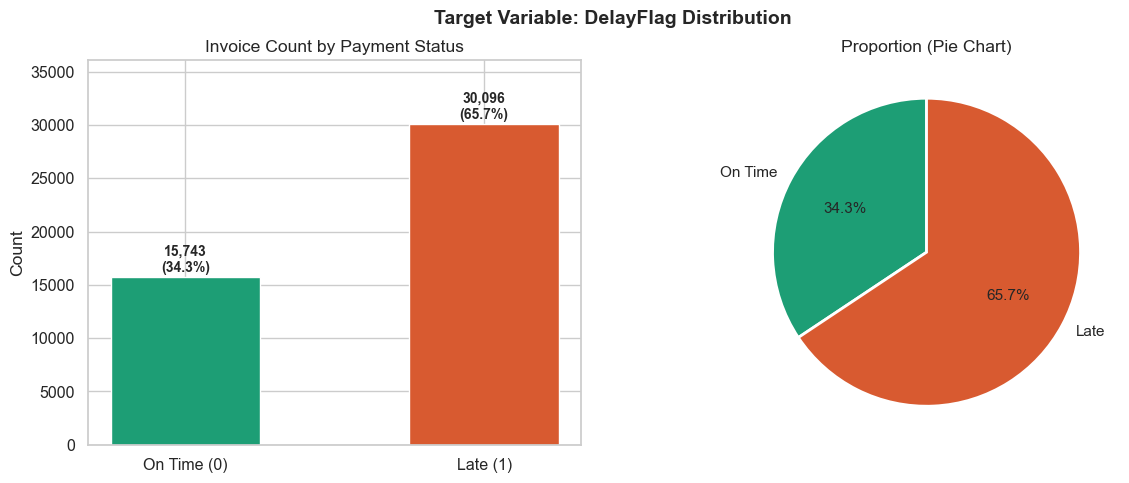

In [14]:

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
fig.suptitle("Target Variable: DelayFlag Distribution", fontsize=14, fontweight="bold")

vc_vals = [vc.get(0, 0), vc.get(1, 0)]
bars = axes[0].bar(["On Time (0)", "Late (1)"], vc_vals,
                   color=[C["teal"], C["coral"]], edgecolor="white", width=0.5)
for bar, val in zip(bars, vc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f"{val:,}\n({val/sum(vc_vals)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_title("Invoice Count by Payment Status")
axes[0].set_ylabel("Count"); axes[0].set_ylim(0, max(vc_vals)*1.2)

axes[1].pie(vc_vals, labels=["On Time", "Late"],
            colors=[C["teal"], C["coral"]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 11})
axes[1].set_title("Proportion (Pie Chart)")

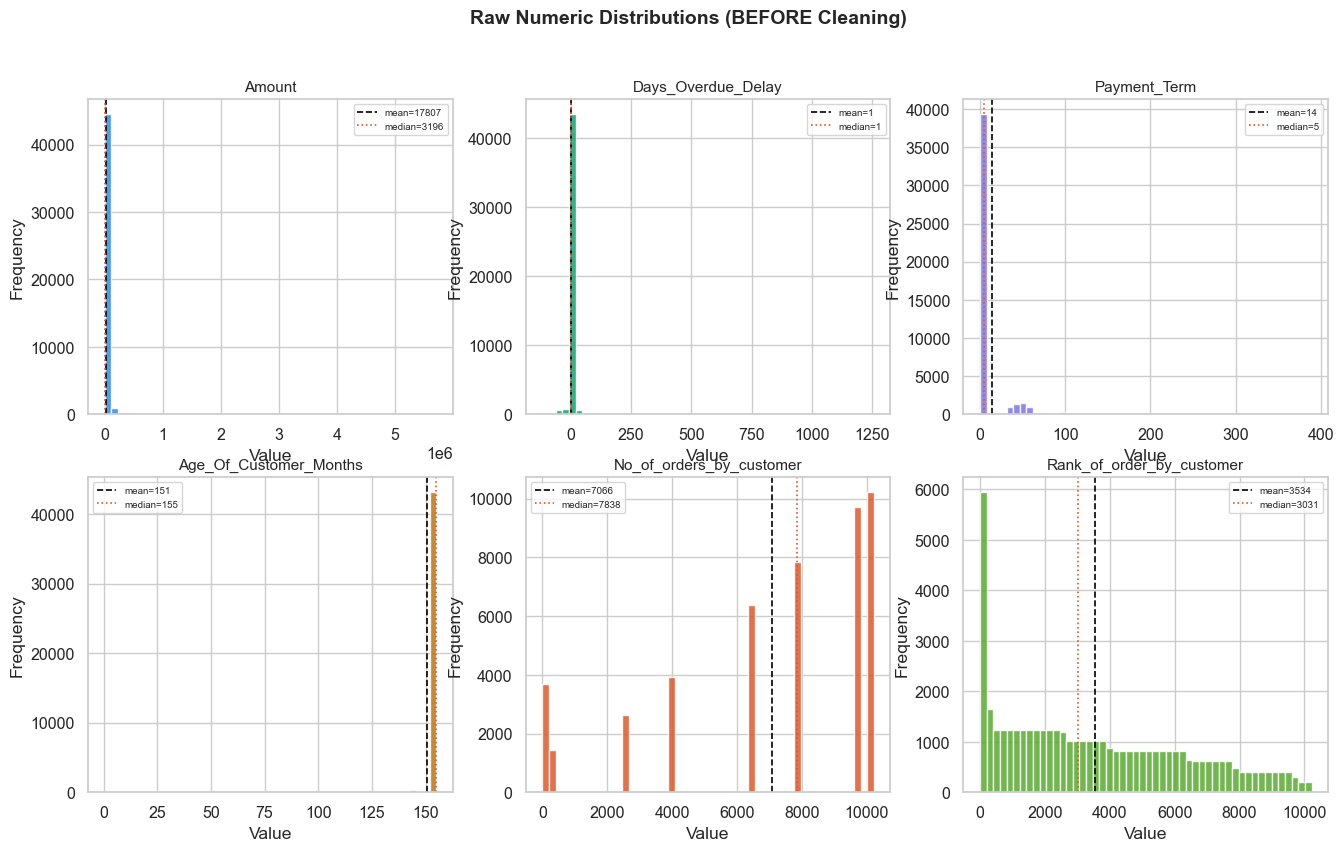

In [15]:
# PLOT 03 — Raw Distributions: Histograms
# ─────────────────────────────────────────────────────────────
plot_num = [AMT, DELAY, PAY_TERM, AGE_MON, N_ORDERS, RANK_ORD]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Raw Numeric Distributions (BEFORE Cleaning)", fontsize=14, fontweight="bold")
colors_list = [C["blue"], C["teal"], C["purple"], C["amber"], C["coral"], C["green"]]
for i, (col, ax) in enumerate(zip(plot_num, axes.flat)):
    data = df_raw[col].dropna()
    ax.hist(data, bins=50, color=colors_list[i], edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Value"); ax.set_ylabel("Frequency")
    ax.axvline(data.mean(),   color="black",    linestyle="--", linewidth=1.2,
               label=f"mean={data.mean():.0f}")
    ax.axvline(data.median(), color=C["coral"], linestyle=":",  linewidth=1.2,
               label=f"median={data.median():.0f}")
    ax.legend(fontsize=7)


## PLOT 04 — Raw Boxplots (outlier visibility)

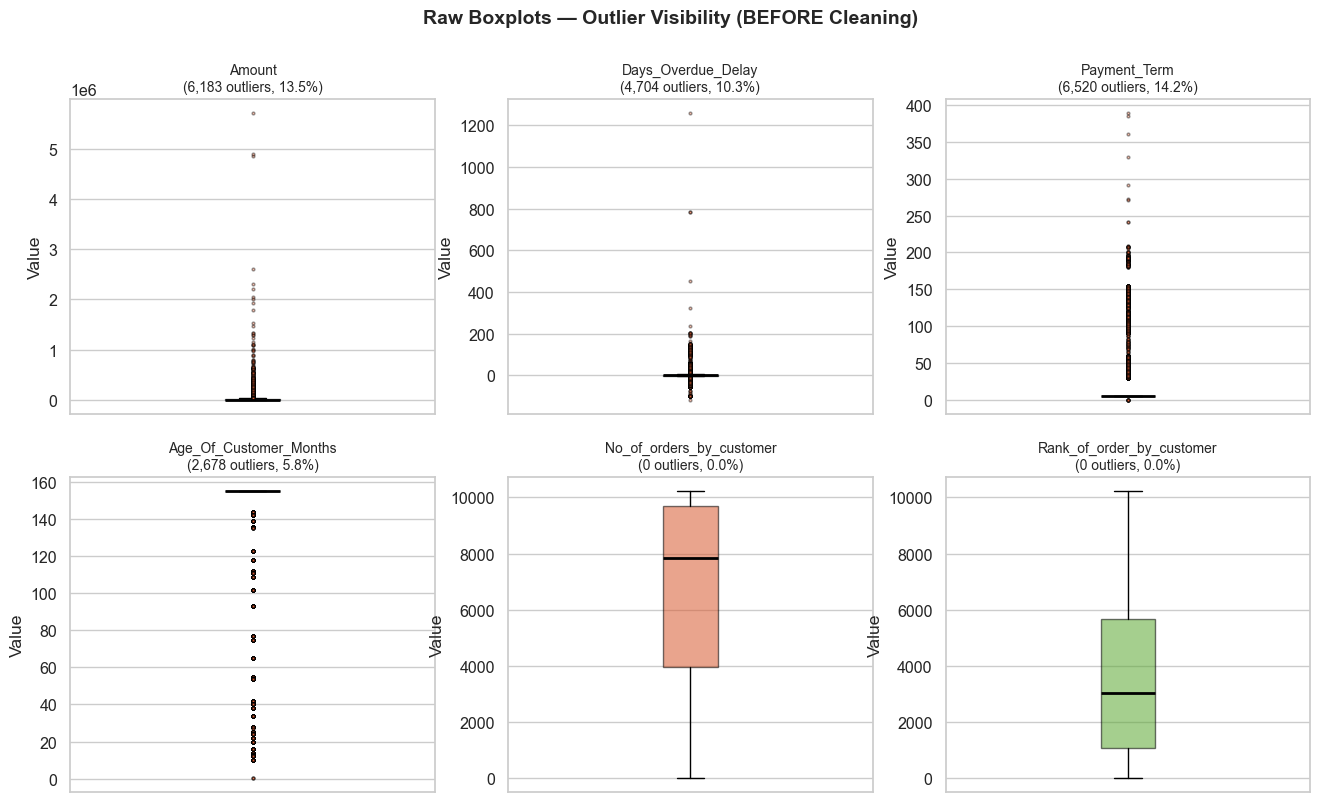

In [16]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Raw Boxplots — Outlier Visibility (BEFORE Cleaning)", fontsize=14, fontweight="bold")
for i, (col, ax) in enumerate(zip(plot_num, axes.flat)):
    data = df_raw[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    n_out  = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors_list[i], alpha=0.55),
                    medianprops=dict(color="black", linewidth=2),
                    flierprops=dict(marker="o", markersize=2,
                                    markerfacecolor=C["coral"], alpha=0.4))
    ax.set_title(f"{col}\n({n_out:,} outliers, {n_out/len(data)*100:.1f}%)", fontsize=10)
    ax.set_ylabel("Value"); ax.set_xticks([])



##  PLOT 05 — Outlier Summary Table (printed + bar chart)


── Outlier summary BEFORE cleaning (IQR method) ──
  Amount                               outliers: 6,183 (13.5%)  fence [-17571, 31379]  skew=35.78
  Days_Overdue_Delay                   outliers: 4,704 (10.3%)  fence [-6, 6]  skew=25.79
  Payment_Term                         outliers: 6,520 (14.2%)  fence [5, 5]  skew=3.95
  Age_Of_Customer_Months               outliers: 2,678 (5.8%)  fence [155, 155]  skew=-5.20
  Age_Of_Customer_Year                 outliers: 2,332 (5.1%)  fence [12, 12]  skew=-5.30
  No_of_orders_by_customer             outliers:     0 (0.0%)  fence [-4730, 18378]  skew=-0.90
  Rank_of_order_by_customer            outliers:     0 (0.0%)  fence [-5867, 12591]  skew=0.51
  Quarter_clearing                     outliers:     0 (0.0%)  fence [-4, 8]  skew=-0.12


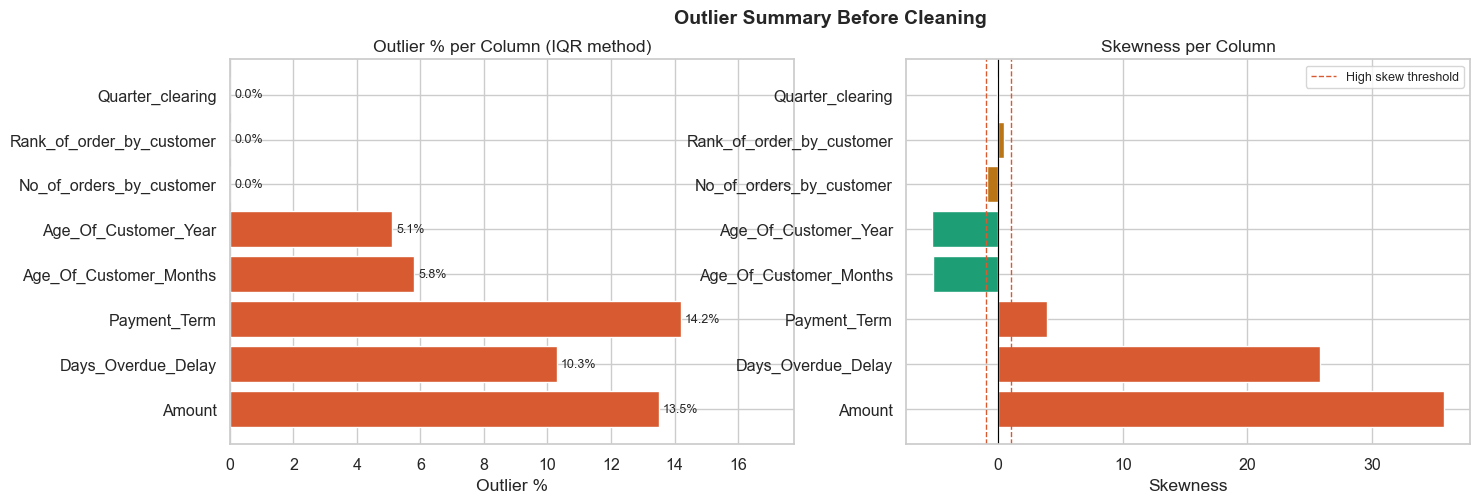

In [17]:


print("\n── Outlier summary BEFORE cleaning (IQR method) ──")
outlier_summary = []
for col in NUM_COLS:
    data = df_raw[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((data < lo) | (data > hi)).sum()
    skew  = float(data.skew())
    outlier_summary.append({
        "Column": col, "Outliers": n_out,
        "Outlier %": round(n_out/len(data)*100, 1),
        "Lower Fence": round(lo, 1), "Upper Fence": round(hi, 1),
        "Min": round(data.min(), 1), "Max": round(data.max(), 1),
        "Skewness": round(skew, 2)
    })
    print(f"  {col:35s}  outliers: {n_out:5,} ({n_out/len(data)*100:.1f}%)  "
          f"fence [{lo:.0f}, {hi:.0f}]  skew={skew:.2f}")

out_df = pd.DataFrame(outlier_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Outlier Summary Before Cleaning", fontsize=14, fontweight="bold")

bars = axes[0].barh(out_df["Column"], out_df["Outlier %"],
                    color=C["coral"], edgecolor="white")
axes[0].bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
axes[0].set_xlabel("Outlier %"); axes[0].set_title("Outlier % per Column (IQR method)")
axes[0].set_xlim(0, out_df["Outlier %"].max() * 1.25)

axes[1].barh(out_df["Column"], out_df["Skewness"],
             color=[C["coral"] if s > 1 else C["teal"] if s < -1 else C["amber"]
                    for s in out_df["Skewness"]],
             edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].axvline( 1, color=C["coral"],  linestyle="--", linewidth=1, label="High skew threshold")
axes[1].axvline(-1, color=C["coral"],  linestyle="--", linewidth=1)
axes[1].set_xlabel("Skewness"); axes[1].set_title("Skewness per Column")
axes[1].legend(fontsize=9)

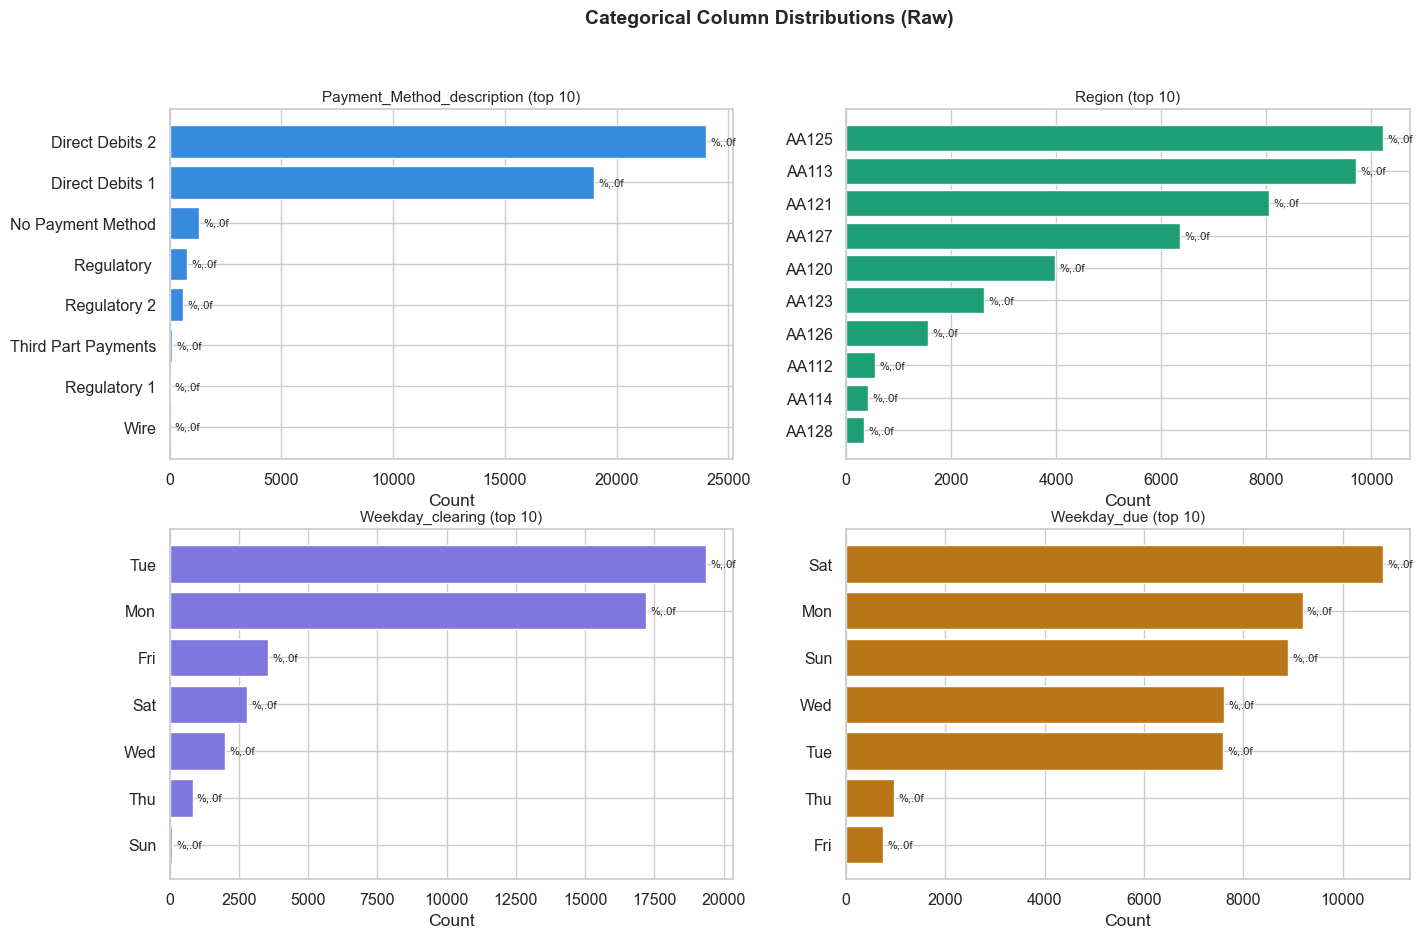

In [18]:
# PLOT 06 — Categorical Distributions (raw)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Categorical Column Distributions (Raw)", fontsize=14, fontweight="bold")
for i, (col, ax) in enumerate(zip(CAT_COLS, axes.flat)):
    vc2 = df_raw[col].value_counts().head(10)
    bars = ax.barh(vc2.index.astype(str), vc2.values,
                   color=colors_list[i % len(colors_list)], edgecolor="white")
    ax.bar_label(bars, fmt="%,.0f", padding=3, fontsize=8)
    ax.set_title(f"{col} (top 10)", fontsize=11)
    ax.set_xlabel("Count"); ax.invert_yaxis()

## PLOT 07 — Correlation Heatmap (raw numeric)

Text(0.5, 1.0, 'Correlation Heatmap — Raw Data (BEFORE Cleaning)')

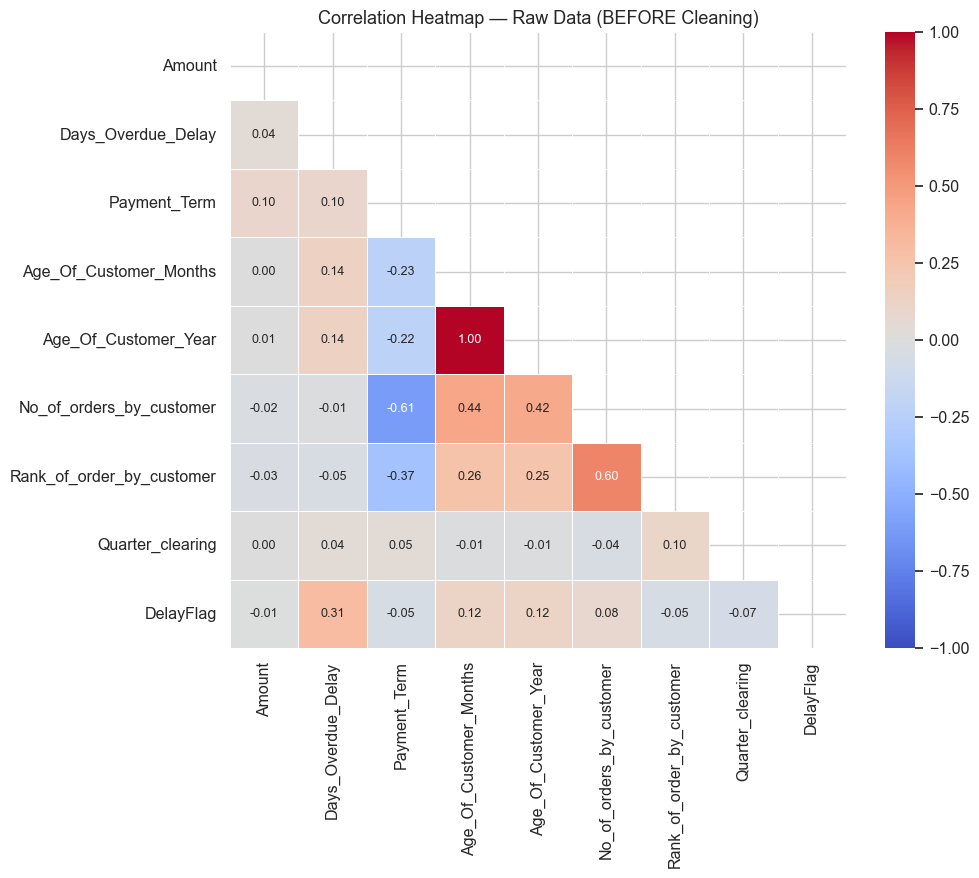

In [19]:
corr_raw = df_raw[NUM_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_raw, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, annot_kws={"size": 9},
            square=True)
ax.set_title("Correlation Heatmap — Raw Data (BEFORE Cleaning)", fontsize=13)

# SECTION 3: DATA CLEANING

In [20]:

section("DATA CLEANING", 3)

df = df_raw.copy()
cleaning_log = []

print("── 3.1 Parsing date columns ──")
for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=False)
    bad = df[col].isnull().sum()
    print(f"  {col}: {bad} unparseable → NaT")
cleaning_log.append(("Parse dates", "4 columns converted to datetime"))

before = len(df)
df = df.dropna(subset=["Net_Due_Date", "Clearing_date"])
dropped = before - len(df)
cleaning_log.append(("Drop missing dates", f"{dropped} rows removed"))
print(f"\n── 3.2 Dropped {dropped} rows with missing Net_Due_Date / Clearing_date ──")

print("\n── 3.3 Missing numeric values (post-date-drop) ──")
for col in NUM_COLS:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        cleaning_log.append((f"Impute {col}", f"{n_miss} filled with median={med:.1f}"))
        print(f"  {col}: filled {n_miss} with median {med:.1f}")
    else:
        print(f"  {col}: no missing values")

print("\n── 3.4 Missing categorical values ──")
for col in CAT_COLS:
    n_miss = df[col].isnull().sum()
    if n_miss > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        cleaning_log.append((f"Impute {col}", f"{n_miss} filled with mode='{mode_val}'"))
        print(f"  {col}: filled {n_miss} with mode '{mode_val}'")
    else:
        print(f"  {col}: no missing values") 

before = len(df)
df = df.drop_duplicates()
dropped_dup = before - len(df)
cleaning_log.append(("Remove duplicates", f"{dropped_dup} rows removed"))
print(f"\n── 3.5 Duplicate rows removed: {dropped_dup} ──")

print("\n── 3.6 Removing invalid values ──")           


════════════════════════════════════════════════════════════
  SECTION 3: DATA CLEANING
════════════════════════════════════════════════════════════
── 3.1 Parsing date columns ──
  Doc_Date: 0 unparseable → NaT
  Net_Due_Date: 0 unparseable → NaT
  Posting_Date: 0 unparseable → NaT
  Clearing_date: 0 unparseable → NaT

── 3.2 Dropped 0 rows with missing Net_Due_Date / Clearing_date ──

── 3.3 Missing numeric values (post-date-drop) ──
  Amount: no missing values
  Days_Overdue_Delay: no missing values
  Payment_Term: no missing values
  Age_Of_Customer_Months: no missing values
  Age_Of_Customer_Year: no missing values
  No_of_orders_by_customer: no missing values
  Rank_of_order_by_customer: no missing values
  Quarter_clearing: no missing values

── 3.4 Missing categorical values ──
  Payment_Method_description: no missing values
  Region: no missing values
  Weekday_clearing: no missing values
  Weekday_due: no missing values

── 3.5 Duplicate rows removed: 0 ──

── 3.6 Removing i

In [21]:
# Negative amounts
before = len(df)
df = df[df[AMT] > 0]
n_neg = before - len(df)
cleaning_log.append(("Remove non-positive Amount", f"{n_neg} rows removed"))
print(f"  Removed {n_neg} rows with Amount <= 0")


  Removed 0 rows with Amount <= 0


In [22]:
# Age of customer cannot be 0 months
before = len(df)
df = df[df[AGE_MON] > 0]
n_age = before - len(df)
cleaning_log.append(("Remove 0-month customers", f"{n_age} rows removed"))
print(f"  Removed {n_age} rows with Age_Of_Customer_Months = 0")

  Removed 0 rows with Age_Of_Customer_Months = 0


In [23]:
# Payment term = 0 is suspicious (no credit term)
n_zero_pt = (df[PAY_TERM] == 0).sum()
print(f"  Rows with Payment_Term=0: {n_zero_pt} (kept — may be immediate payment)")

  Rows with Payment_Term=0: 9 (kept — may be immediate payment)


## OUTLIER CAPPING

In [24]:
print("\n── 3.7 Outlier capping via IQR Winsorization ──")
# Cap instead of drop: preserves volume, removes extreme distortion
CAP_COLS = [AMT, DELAY, PAY_TERM]

before_after = {}
for col in CAP_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_cap = ((df[col] < lo) | (df[col] > hi)).sum()
    before_after[col] = {
        "before_min": df[col].min(), "before_max": df[col].max(),
        "before_mean": df[col].mean(),
        "lower_fence": lo, "upper_fence": hi, "n_capped": n_cap
    }
    df[col] = df[col].clip(lower=lo, upper=hi)
    before_after[col]["after_min"]  = df[col].min()
    before_after[col]["after_max"]  = df[col].max()
    before_after[col]["after_mean"] = df[col].mean()
    cleaning_log.append((f"Cap outliers {col}", f"{n_cap} values capped [{lo:.0f},{hi:.0f}]"))
    print(f"  {col}: capped {n_cap:,} values  "
          f"range [{before_after[col]['before_min']:.0f},{before_after[col]['before_max']:.0f}]"
          f" → [{before_after[col]['after_min']:.0f},{before_after[col]['after_max']:.0f}]")


── 3.7 Outlier capping via IQR Winsorization ──
  Amount: capped 6,183 values  range [2,5709354] → [2,31379]
  Days_Overdue_Delay: capped 4,704 values  range [-117,1257] → [-6,6]
  Payment_Term: capped 6,520 values  range [0,389] → [5,5]


## SUMMARY OF CLEANING

In [25]:
print(f"\n── 3.8 Cleaning summary ──")
print(f"  Rows before : {len(df_raw):,}")
print(f"  Rows after  : {len(df):,}")
print(f"  Rows removed: {len(df_raw)-len(df):,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")
print(f"  Missing remaining: {df.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df.duplicated().sum()}")
print(f"\nCleaning log:")
for step, detail in cleaning_log:
    print(f"  ✓ {step:<35s} {detail}")


── 3.8 Cleaning summary ──
  Rows before : 45,839
  Rows after  : 45,839
  Rows removed: 0 (0.0%)
  Missing remaining: 0


  Duplicates remaining: 0

Cleaning log:
  ✓ Parse dates                         4 columns converted to datetime
  ✓ Drop missing dates                  0 rows removed
  ✓ Remove duplicates                   0 rows removed
  ✓ Remove non-positive Amount          0 rows removed
  ✓ Remove 0-month customers            0 rows removed
  ✓ Cap outliers Amount                 6183 values capped [-17571,31379]
  ✓ Cap outliers Days_Overdue_Delay     4704 values capped [-6,6]
  ✓ Cap outliers Payment_Term           6520 values capped [5,5]


## SECTION 4: VISUALISATION AFTER CLEANING


════════════════════════════════════════════════════════════
  SECTION 4: VISUALISATION AFTER CLEANING
════════════════════════════════════════════════════════════


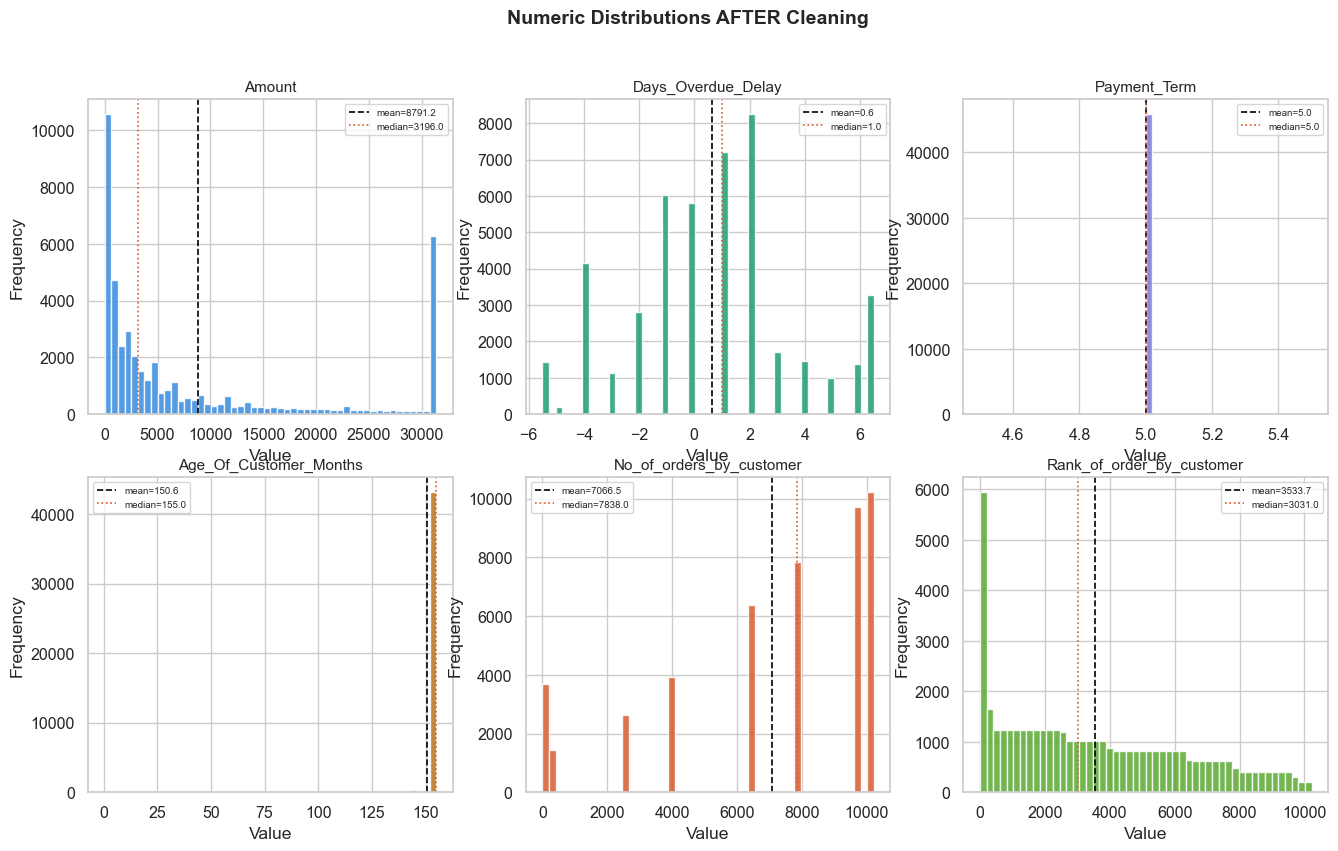

In [26]:

section("VISUALISATION AFTER CLEANING", 4)


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numeric Distributions AFTER Cleaning", fontsize=14, fontweight="bold")
for i, (col, ax) in enumerate(zip(plot_num, axes.flat)):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=colors_list[i], edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("Value"); ax.set_ylabel("Frequency")
    ax.axvline(data.mean(),   color="black",    linestyle="--", linewidth=1.2,
               label=f"mean={data.mean():.1f}")
    ax.axvline(data.median(), color=C["coral"], linestyle=":",  linewidth=1.2,
               label=f"median={data.median():.1f}")
    ax.legend(fontsize=7)

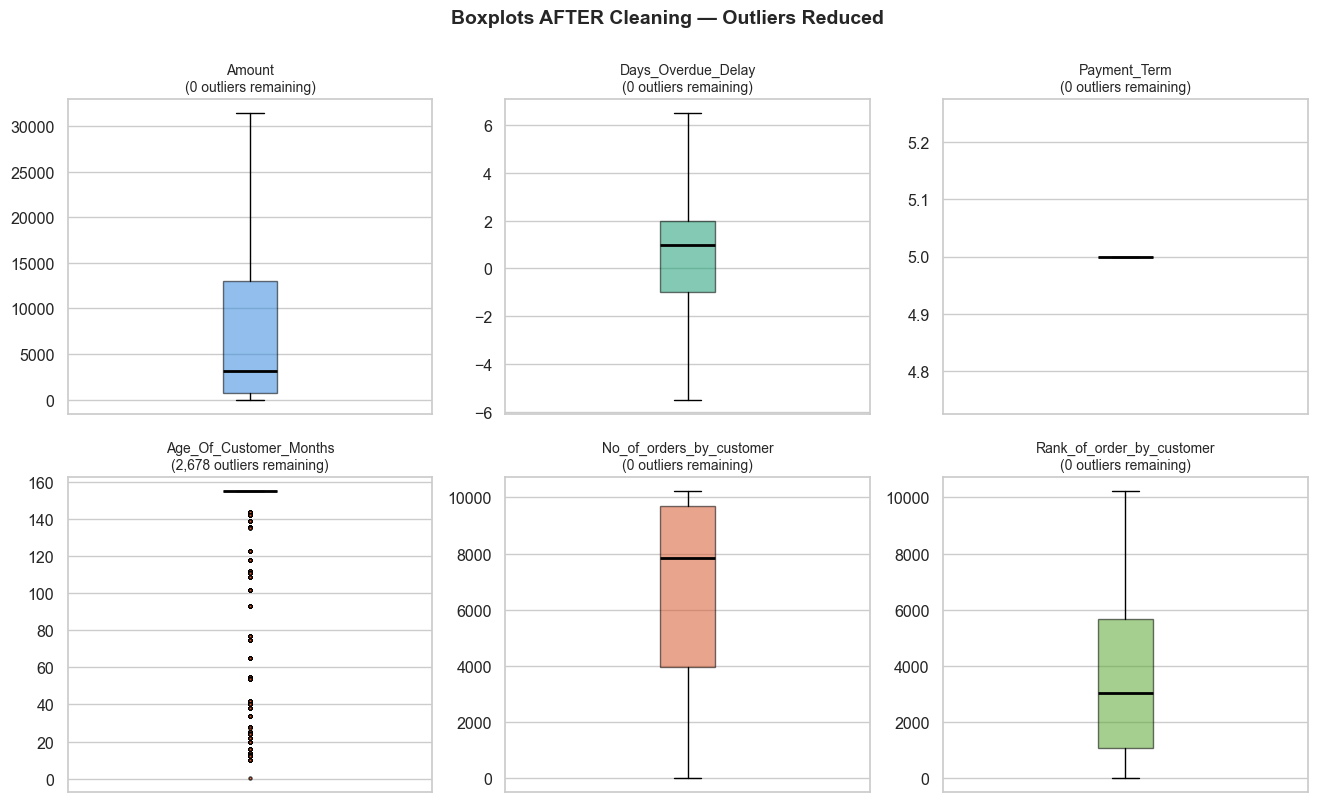

In [27]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Boxplots AFTER Cleaning — Outliers Reduced", fontsize=14, fontweight="bold")
for i, (col, ax) in enumerate(zip(plot_num, axes.flat)):
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr    = q3 - q1
    n_out  = ((data < q1-1.5*iqr) | (data > q3+1.5*iqr)).sum()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=colors_list[i], alpha=0.55),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker="o", markersize=2,
                               markerfacecolor=C["coral"], alpha=0.4))
    ax.set_title(f"{col}\n({n_out:,} outliers remaining)", fontsize=10)
    ax.set_xticks([])

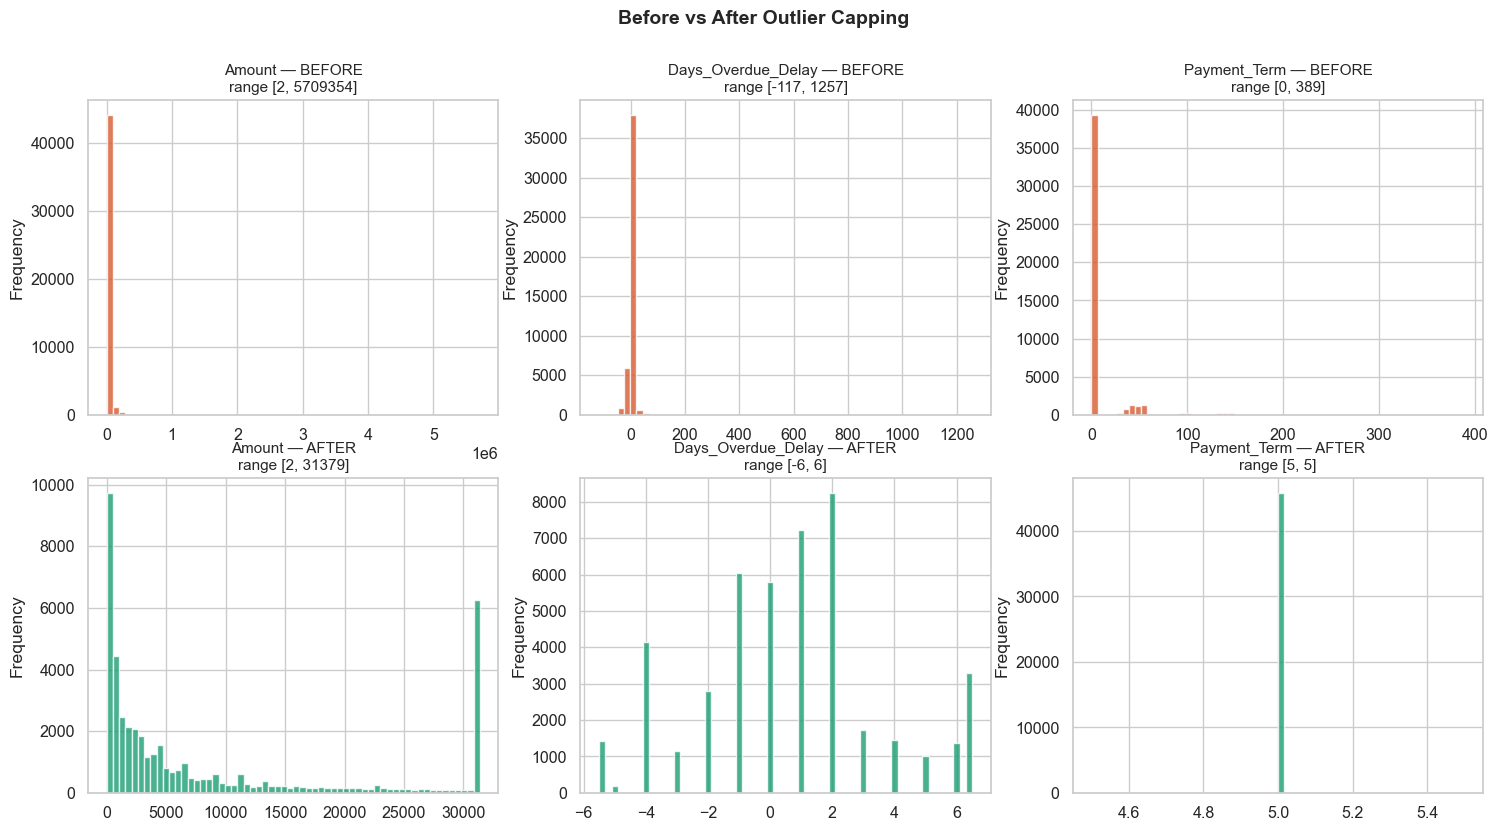

In [28]:
# PLOT 10 — Before vs After side-by-side for capped columns
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, len(CAP_COLS), figsize=(6*len(CAP_COLS), 9))
fig.suptitle("Before vs After Outlier Capping", fontsize=14, fontweight="bold")
for i, col in enumerate(CAP_COLS):
    raw_data   = df_raw[col].dropna()
    clean_data = df[col].dropna()
    axes[0][i].hist(raw_data,   bins=60, color=C["coral"], edgecolor="white", alpha=0.8)
    axes[0][i].set_title(f"{col} — BEFORE\n"
                          f"range [{raw_data.min():.0f}, {raw_data.max():.0f}]", fontsize=11)
    axes[0][i].set_ylabel("Frequency")
    axes[1][i].hist(clean_data, bins=60, color=C["teal"], edgecolor="white", alpha=0.8)
    axes[1][i].set_title(f"{col} — AFTER\n"
                          f"range [{clean_data.min():.0f}, {clean_data.max():.0f}]", fontsize=11)
    axes[1][i].set_ylabel("Frequency")

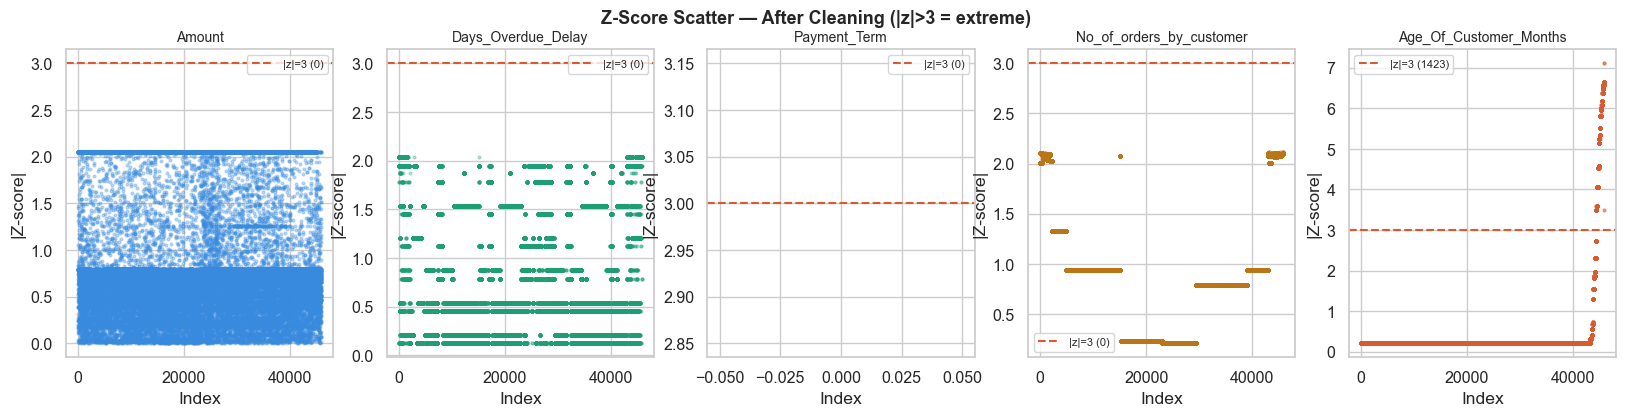

In [29]:

Z_COLS = [AMT, DELAY, PAY_TERM, N_ORDERS, AGE_MON]
Z_COLS = [c for c in Z_COLS if c in df.columns]
fig, axes = plt.subplots(1, len(Z_COLS), figsize=(4*len(Z_COLS), 4))
fig.suptitle("Z-Score Scatter — After Cleaning (|z|>3 = extreme)", fontsize=13, fontweight="bold")
for i, (col, ax) in enumerate(zip(Z_COLS, axes)):
    data      = df[col].dropna().values
    z         = np.abs(stats.zscore(data))
    n_extreme = (z > 3).sum()
    ax.scatter(range(len(z)), z, s=4, alpha=0.3, color=colors_list[i])
    ax.axhline(3, color=C["coral"], linestyle="--", linewidth=1.5,
               label=f"|z|=3 ({n_extreme})")
    ax.set_title(f"{col}", fontsize=10)
    ax.set_xlabel("Index"); ax.set_ylabel("|Z-score|")
    ax.legend(fontsize=8)

Text(0.5, 1.0, 'Correlation Heatmap — AFTER Cleaning')

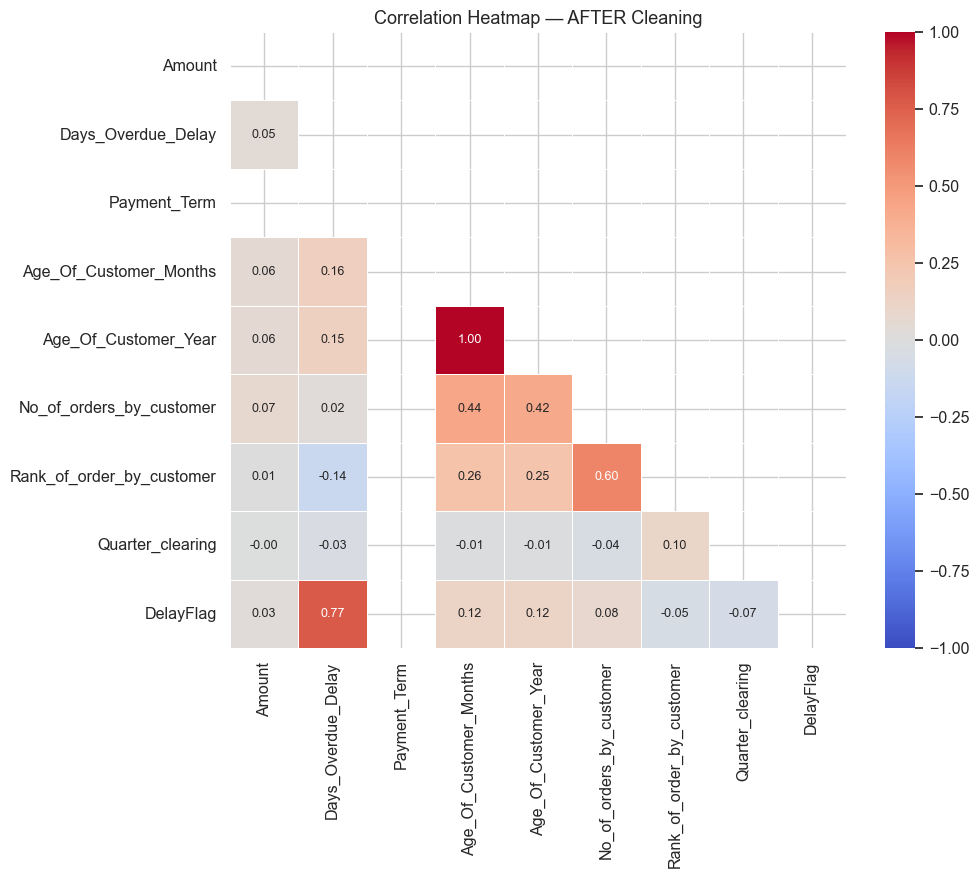

In [30]:

corr_clean = df[NUM_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr_clean, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, ax=ax, linewidths=0.5,
            vmin=-1, vmax=1, annot_kws={"size": 9}, square=True)
ax.set_title("Correlation Heatmap — AFTER Cleaning", fontsize=13)

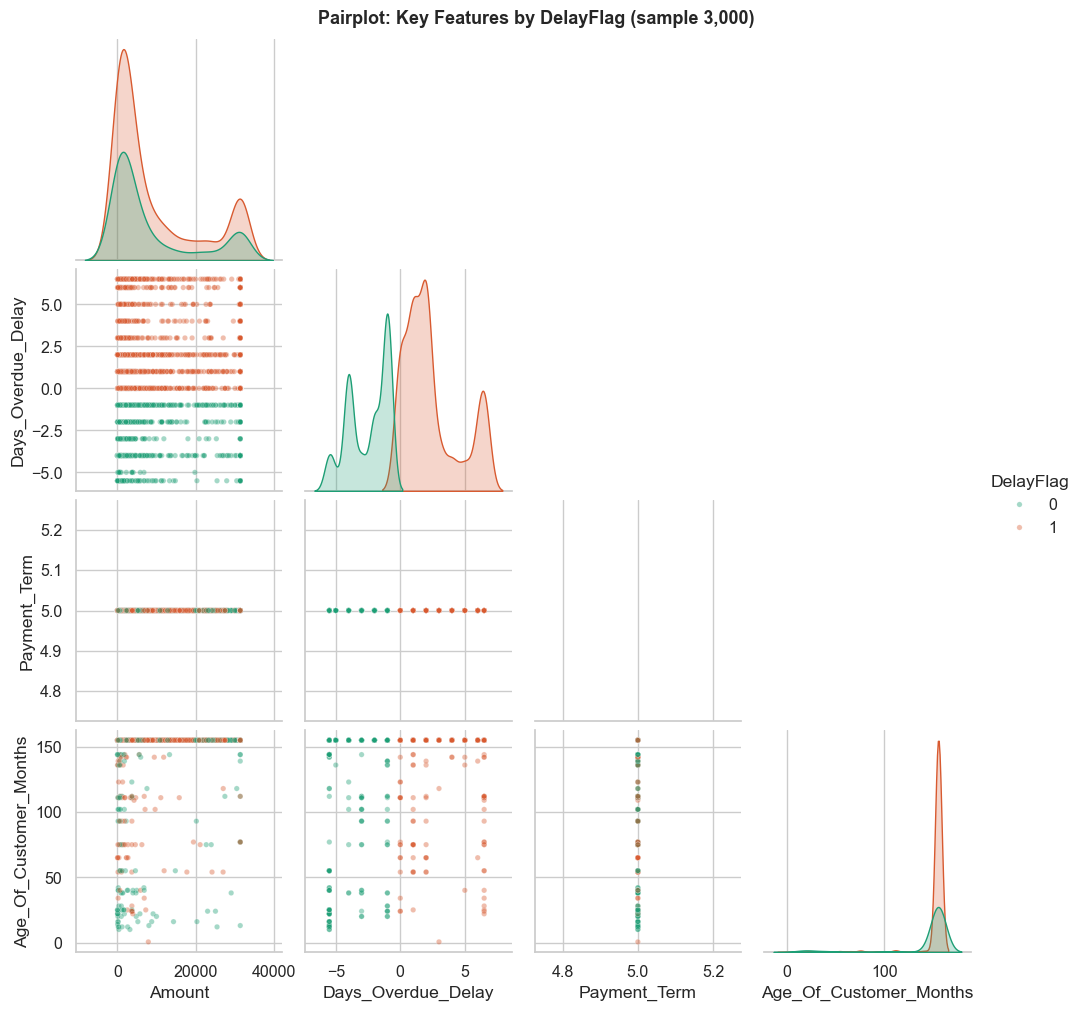

  → plots/13_pairplot.png


In [31]:

pair_cols = [AMT, DELAY, PAY_TERM, AGE_MON, TARGET]
pair_df   = df[pair_cols].sample(min(3000, len(df)), random_state=42)
g = sns.pairplot(pair_df, hue=TARGET, palette={0: C["teal"], 1: C["coral"]},
                 diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15},
                 corner=True)
g.fig.suptitle("Pairplot: Key Features by DelayFlag (sample 3,000)",
               y=1.01, fontsize=13, fontweight="bold")
plt.show(); print("  → plots/13_pairplot.png")

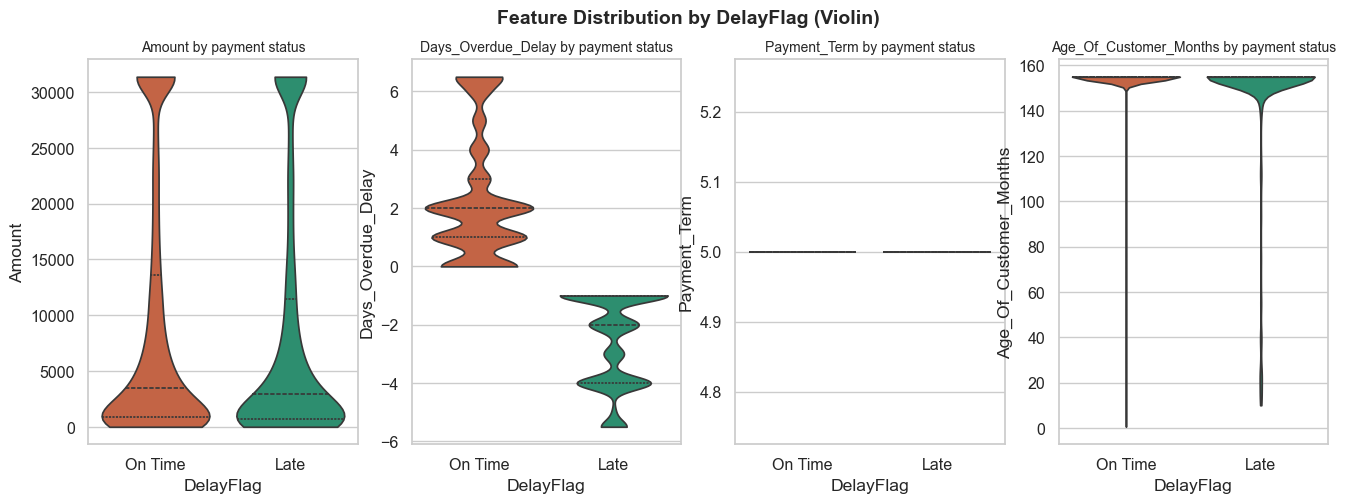

In [32]:

violin_cols = [AMT, DELAY, PAY_TERM, AGE_MON]
fig, axes = plt.subplots(1, len(violin_cols), figsize=(16, 5))
fig.suptitle("Feature Distribution by DelayFlag (Violin)", fontsize=14, fontweight="bold")
for i, (col, ax) in enumerate(zip(violin_cols, axes)):
    df_v = df.copy(); df_v[TARGET] = df_v[TARGET].astype(str)
    sns.violinplot(x=TARGET, y=col, data=df_v, ax=ax,
                   hue=TARGET,
                   palette={"0": C["teal"], "1": C["coral"]},
                   inner="quartile", cut=0, legend=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["On Time", "Late"])
    ax.set_title(f"{col} by payment status", fontsize=10)


── Feature correlations with DelayFlag ──
Quarter_clearing            -0.066
Rank_of_order_by_customer   -0.051
Amount                       0.030
No_of_orders_by_customer     0.084
Age_Of_Customer_Year         0.119
Age_Of_Customer_Months       0.122
Days_Overdue_Delay           0.768
Payment_Term                   NaN


Text(0.5, 1.0, 'Feature Correlation with Target (DelayFlag)')

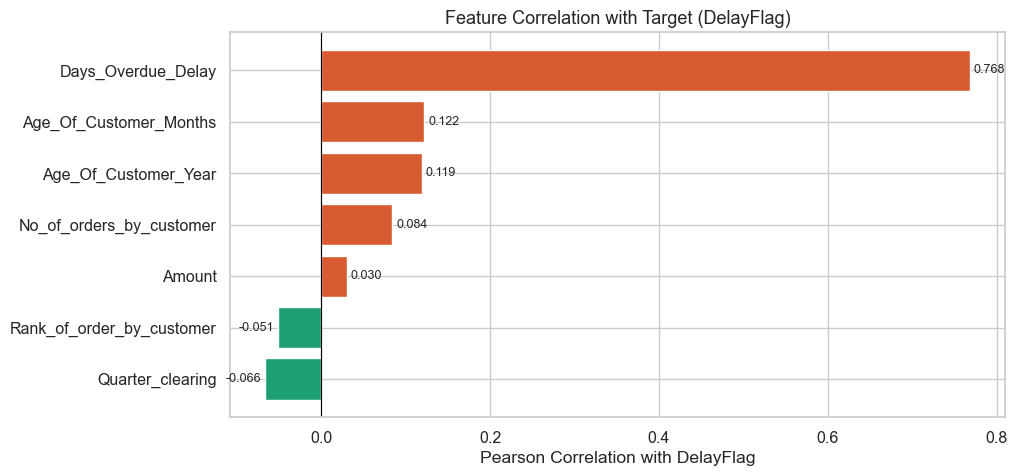

In [33]:

target_corr = df[NUM_COLS].corrwith(df[TARGET]).sort_values()
print("\n── Feature correlations with DelayFlag ──")
print(target_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [C["coral"] if v > 0 else C["teal"] for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with DelayFlag")
ax.set_title("Feature Correlation with Target (DelayFlag)", fontsize=13)


── Categorical feature relationship with DelayFlag ──

  Payment_Method_description:
Payment_Method_description
Third Part Payments    81.6
No Payment Method      80.9
Direct Debits 2        72.4
Direct Debits 1        59.7
Regulatory 1           53.5
Wire                   37.5
Regulatory 2           25.2
Regulatory              7.0

  Weekday_due:
Weekday_due
Mon    94.9
Sun    91.4
Tue    68.0
Sat    52.7
Fri    40.7
Thu    24.6
Wed    24.1

  Weekday_clearing:
Weekday_clearing
Sat    100.0
Sun    100.0
Wed     85.1
Mon     67.2
Thu     63.8
Fri     62.2
Tue     57.9


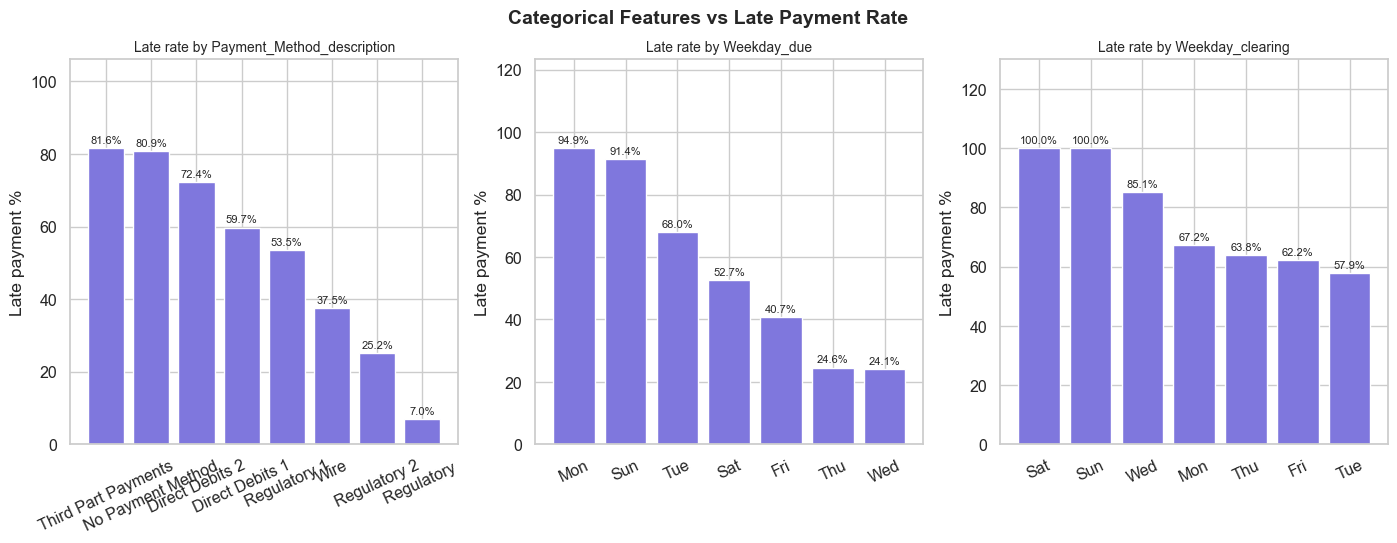

In [34]:

print("\n── Categorical feature relationship with DelayFlag ──")
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Categorical Features vs Late Payment Rate", fontsize=14, fontweight="bold")

cat_plot_cols = [
    ("Payment_Method_description", axes[0]),
    ("Weekday_due",               axes[1]),
    ("Weekday_clearing",          axes[2]),
]
for col, ax in cat_plot_cols:
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    bars = ax.bar(rate.index.astype(str), rate.values * 100,
                  color=C["purple"], edgecolor="white")
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8)
    ax.set_title(f"Late rate by {col}", fontsize=10)
    ax.set_ylabel("Late payment %"); ax.tick_params(axis="x", rotation=25)
    ax.set_ylim(0, rate.max() * 1.3 * 100)
    print(f"\n  {col}:\n{(rate*100).round(1).to_string()}")

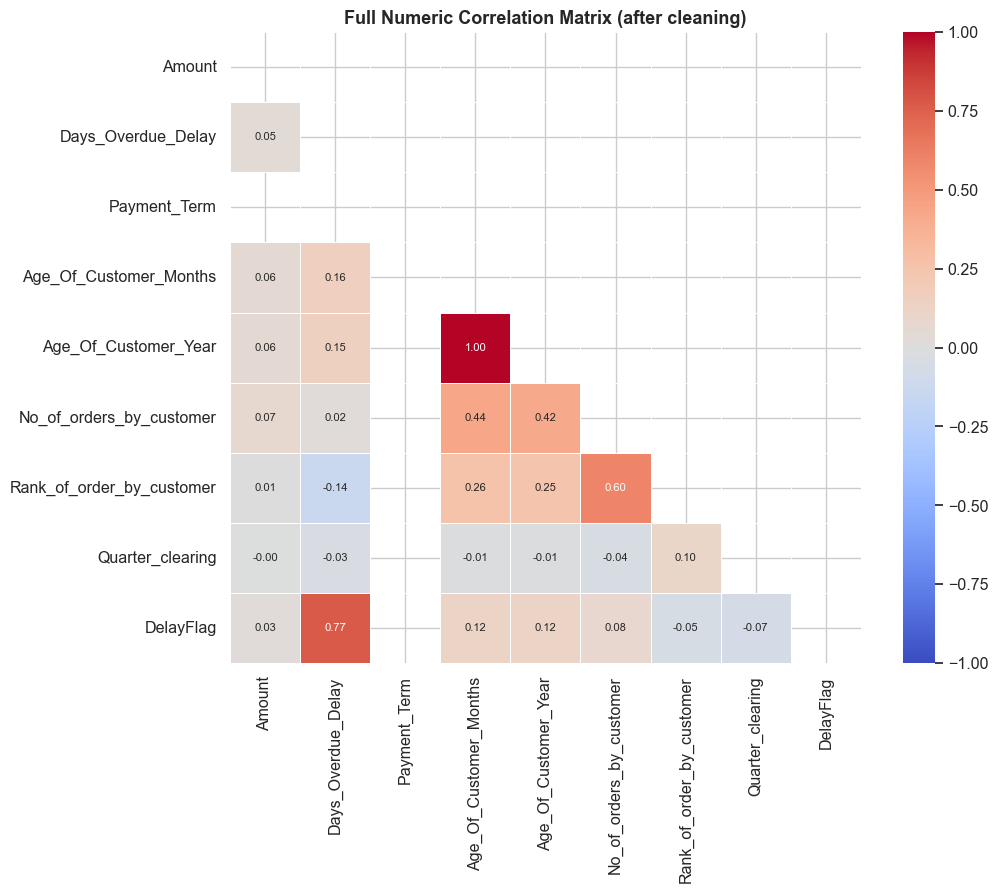

In [35]:

corr_full = df[NUM_COLS + [TARGET]].corr()

fig17, ax17 = plt.subplots(figsize=(11, 9))
mask17 = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask17, ax=ax17, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size": 8}, square=True)
ax17.set_title("Full Numeric Correlation Matrix (after cleaning)", fontsize=13, fontweight="bold")
fig17.tight_layout()
plt.show()

# SECTION 6: FEATURE ENGINEERING

In [36]:

section("FEATURE ENGINEERING", 6)

df_fe = df.copy()

# ── 6.1 Date-derived features ────────────────────────────────
print("── 6.1 Date-derived features ──")
df_fe["invoice_month"]     = df_fe["Posting_Date"].dt.month
df_fe["invoice_quarter"]   = df_fe["Posting_Date"].dt.quarter
df_fe["invoice_dayofweek"] = df_fe["Posting_Date"].dt.dayofweek
df_fe["invoice_dayofmonth"]= df_fe["Posting_Date"].dt.day
df_fe["clearing_month"]    = df_fe["Clearing_date"].dt.month
df_fe["clearing_quarter"]  = df_fe["Clearing_date"].dt.quarter

# Credit period and actual overdue from dates
df_fe["credit_period_days"] = (df_fe["Net_Due_Date"] - df_fe["Posting_Date"]).dt.days
df_fe["actual_days_overdue"]= (df_fe["Clearing_date"] - df_fe["Net_Due_Date"]).dt.days
df_fe["days_to_clear"]      = (df_fe["Clearing_date"] - df_fe["Posting_Date"]).dt.days

# Month-end pressure (invoice issued in last 5 days of month)
df_fe["is_month_end_invoice"] = (df_fe["invoice_dayofmonth"] >= 26).astype(int)

# Weekend invoice
df_fe["is_weekend_invoice"] = (df_fe["invoice_dayofweek"] >= 5).astype(int)

for col in ["invoice_month","invoice_quarter","invoice_dayofweek",
            "credit_period_days","actual_days_overdue","days_to_clear"]:
    print(f"  {col}: {df_fe[col].describe()[['min','mean','max']].to_dict()}")
  



════════════════════════════════════════════════════════════
  SECTION 6: FEATURE ENGINEERING
════════════════════════════════════════════════════════════
── 6.1 Date-derived features ──
  invoice_month: {'min': 1.0, 'mean': 6.508737101594712, 'max': 12.0}
  invoice_quarter: {'min': 1.0, 'mean': 2.5055956718078494, 'max': 4.0}
  invoice_dayofweek: {'min': 0.0, 'mean': 1.8056676629071315, 'max': 4.0}
  credit_period_days: {'min': 0.0, 'mean': 13.79264381858243, 'max': 389.0}
  actual_days_overdue: {'min': -117.0, 'mean': 0.9673640349920374, 'max': 1257.0}
  days_to_clear: {'min': 0.0, 'mean': 14.760007853574468, 'max': 1437.0}


In [37]:
# ── 6.2 Customer-level aggregated lag features ───────────────
print("\n── 6.2 Customer-level lag features ──")
df_fe = df_fe.sort_values([CUST, "Posting_Date"]).reset_index(drop=True)

# Rolling historical late rate (shift to prevent leakage)
df_fe["cust_hist_late_rate"] = (
    df_fe.groupby(CUST)[TARGET]
         .transform(lambda x: x.shift(1).expanding().mean())
         .fillna(0.5)   # neutral prior for first invoice
)
# Rolling avg days overdue
df_fe["cust_hist_avg_overdue"] = (
    df_fe.groupby(CUST)[DELAY]
         .transform(lambda x: x.shift(1).expanding().mean())
         .fillna(0.0)
)
# Invoice sequence number per customer
df_fe["cust_invoice_seq"] = df_fe.groupby(CUST).cumcount() + 1

# Customer order volume ratio (rank / total orders)
df_fe["order_volume_ratio"] = (
    df_fe[RANK_ORD] / df_fe[N_ORDERS].replace(0, 1)
)

print(f"  cust_hist_late_rate   : mean={df_fe['cust_hist_late_rate'].mean():.3f}")
print(f"  cust_hist_avg_overdue : mean={df_fe['cust_hist_avg_overdue'].mean():.2f}")
print(f"  cust_invoice_seq      : max={df_fe['cust_invoice_seq'].max()}")
print(f"  order_volume_ratio    : mean={df_fe['order_volume_ratio'].mean():.3f}")


── 6.2 Customer-level lag features ──


  cust_hist_late_rate   : mean=0.721
  cust_hist_avg_overdue : mean=1.04
  cust_invoice_seq      : max=10219
  order_volume_ratio    : mean=0.501


In [38]:
# ── 6.3 Amount-based features ───────────────────────────────
print("\n── 6.3 Amount-based features ──")
df_fe["log_amount"]        = np.log1p(df_fe[AMT])
df_fe["amount_per_day"]    = df_fe[AMT] / df_fe["credit_period_days"].replace(0, 1)
df_fe["is_large_invoice"]  = (df_fe[AMT] > df_fe[AMT].quantile(0.75)).astype(int)
df_fe["is_small_invoice"]  = (df_fe[AMT] < df_fe[AMT].quantile(0.25)).astype(int)

print(f"  log_amount       : mean={df_fe['log_amount'].mean():.2f}")
print(f"  amount_per_day   : mean={df_fe['amount_per_day'].mean():.2f}")
print(f"  is_large_invoice : {df_fe['is_large_invoice'].mean()*100:.1f}% of invoices")

# ── 6.4 Payment term buckets ────────────────────────────────
print("\n── 6.4 Payment term bucket features ──")
df_fe["pt_bucket"] = pd.cut(df_fe[PAY_TERM],
                              bins=[0, 30, 60, 90, 120, np.inf],
                              labels=["0-30","31-60","61-90","91-120","120+"],
                              include_lowest=True)
df_fe["pt_bucket_code"] = df_fe["pt_bucket"].cat.codes


── 6.3 Amount-based features ──
  log_amount       : mean=7.86
  amount_per_day   : mean=1568.32
  is_large_invoice : 25.0% of invoices

── 6.4 Payment term bucket features ──


In [39]:
# Late rate per payment term bucket
pt_late = df_fe.groupby("pt_bucket")[TARGET].mean()
print(f"\n  Late rate by payment term bucket:\n{(pt_late*100).round(1).to_string()}")


  Late rate by payment term bucket:
pt_bucket
0-30    65.7


In [40]:
# ── 6.5 Interaction features ────────────────────────────────
print("\n── 6.5 Interaction features ──")
df_fe["amount_x_payterm"]    = df_fe[AMT]    * df_fe[PAY_TERM]
df_fe["amount_x_hist_late"]  = df_fe["log_amount"] * df_fe["cust_hist_late_rate"]
df_fe["payterm_x_hist_late"] = df_fe[PAY_TERM] * df_fe["cust_hist_late_rate"]
df_fe["age_x_orders"]        = df_fe[AGE_MON] * df_fe[N_ORDERS]
print("  Created: amount_x_payterm, amount_x_hist_late, payterm_x_hist_late, age_x_orders")


── 6.5 Interaction features ──
  Created: amount_x_payterm, amount_x_hist_late, payterm_x_hist_late, age_x_orders


In [41]:
# ── 6.6 Encode categoricals ─────────────────────────────────
print("\n── 6.6 Label encoding categoricals ──")
le = LabelEncoder()
for col in ["Payment_Method_description", "Region"]:
    df_fe[f"{col}_enc"] = le.fit_transform(df_fe[col].astype(str))
    print(f"  {col} → {col}_enc ({df_fe[col].nunique()} classes)")


── 6.6 Label encoding categoricals ──
  Payment_Method_description → Payment_Method_description_enc (8 classes)


  Region → Region_enc (30 classes)


## 6.7 Final feature set

In [42]:
print("\n── 6.7 Final ML feature list ──")
ML_FEATURES = [
    # Original cleaned
    AMT, PAY_TERM, AGE_MON, N_ORDERS, RANK_ORD,
    QTR, WD_CLEAR, WD_DUE,
    # Date-derived
    "invoice_month", "invoice_quarter", "invoice_dayofweek",
    "invoice_dayofmonth", "credit_period_days",
    "is_month_end_invoice", "is_weekend_invoice",
    # Customer history
    "cust_hist_late_rate", "cust_hist_avg_overdue",
    "cust_invoice_seq", "order_volume_ratio",
    # Amount features
    "log_amount", "amount_per_day",
    "is_large_invoice", "is_small_invoice",
    # Payment term bucket
    "pt_bucket_code",
    # Interaction features
    "amount_x_payterm", "amount_x_hist_late",
    "payterm_x_hist_late", "age_x_orders",
    # Encoded categoricals
    "Payment_Method_description_enc", "Region_enc",
]
print(f"  Total features: {len(ML_FEATURES)}")
for i, f in enumerate(ML_FEATURES, 1):
    print(f"    {i:2d}. {f}")

X = df_fe[ML_FEATURES].fillna(0)
y = df_fe[TARGET]
print(f"\n  X shape: {X.shape},  y shape: {y.shape}")
print(f"  Late rate in y: {y.mean():.2%}")


── 6.7 Final ML feature list ──
  Total features: 30
     1. Amount
     2. Payment_Term
     3. Age_Of_Customer_Months
     4. No_of_orders_by_customer
     5. Rank_of_order_by_customer
     6. Quarter_clearing
     7. Weekday_clearnum
     8. Weekday_due.1
     9. invoice_month
    10. invoice_quarter
    11. invoice_dayofweek
    12. invoice_dayofmonth
    13. credit_period_days
    14. is_month_end_invoice
    15. is_weekend_invoice
    16. cust_hist_late_rate
    17. cust_hist_avg_overdue
    18. cust_invoice_seq
    19. order_volume_ratio
    20. log_amount
    21. amount_per_day
    22. is_large_invoice
    23. is_small_invoice
    24. pt_bucket_code
    25. amount_x_payterm
    26. amount_x_hist_late
    27. payterm_x_hist_late
    28. age_x_orders
    29. Payment_Method_description_enc
    30. Region_enc

  X shape: (45839, 30),  y shape: (45839,)
  Late rate in y: 65.66%


## Feature engineering overview

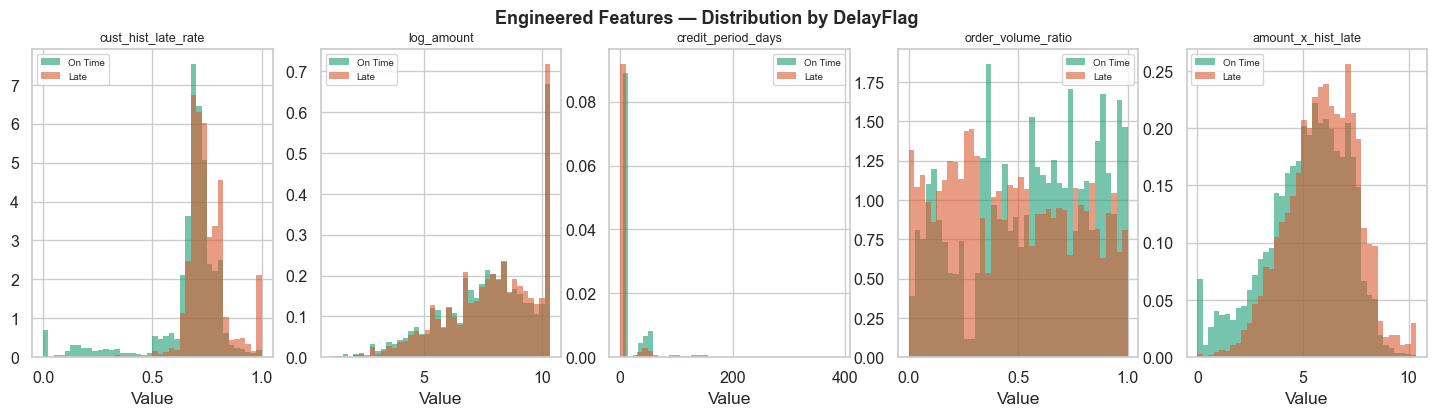

In [43]:

new_feats = ["cust_hist_late_rate","log_amount","credit_period_days",
             "order_volume_ratio","amount_x_hist_late"]
fig, axes = plt.subplots(1, len(new_feats), figsize=(18, 4))
fig.suptitle("Engineered Features — Distribution by DelayFlag", fontsize=13, fontweight="bold")
for i, (col, ax) in enumerate(zip(new_feats, axes)):
    for flag, color, label in [(0, C["teal"], "On Time"), (1, C["coral"], "Late")]:
        ax.hist(df_fe.loc[df_fe[TARGET]==flag, col], bins=40, alpha=0.6,
                color=color, label=label, density=True, edgecolor="none")
    ax.set_title(col, fontsize=9); ax.set_xlabel("Value")
    ax.legend(fontsize=7)

##  PLOT 19 — Correlation of all features with target

Text(0.5, 1.0, 'All Engineered Features — Correlation with Target')

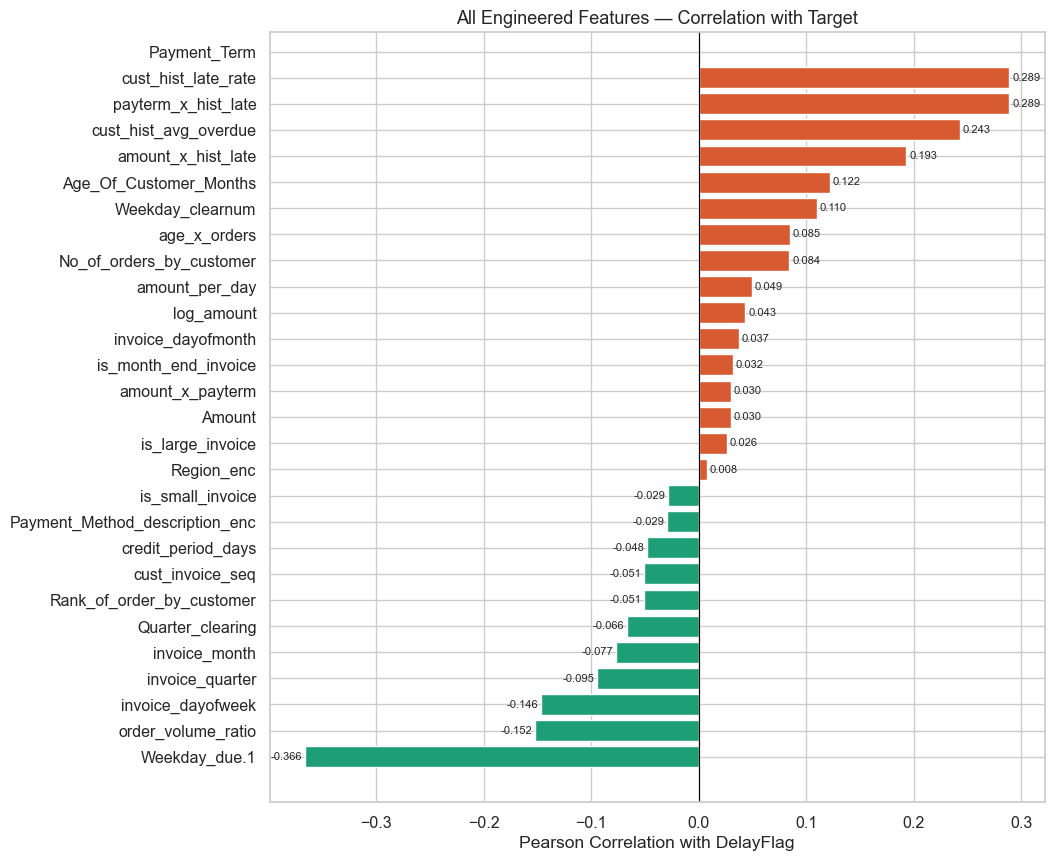

In [44]:
all_corr = X.corrwith(y).sort_values()
fig, ax = plt.subplots(figsize=(10, 10))
colors_all = [C["coral"] if v > 0 else C["teal"] for v in all_corr.values]
bars = ax.barh(all_corr.index, all_corr.values, color=colors_all, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with DelayFlag")
ax.set_title("All Engineered Features — Correlation with Target", fontsize=13)

# SECTION 7: POLYNOMIAL FEATURE ENGINEERING


════════════════════════════════════════════════════════════
  SECTION 7: POLYNOMIAL FEATURE ENGINEERING
════════════════════════════════════════════════════════════
Top 5 features for polynomial expansion:
  ['Weekday_due.1', 'cust_hist_late_rate', 'payterm_x_hist_late', 'cust_hist_avg_overdue', 'amount_x_hist_late']
  Correlation magnitudes:
Weekday_due.1            0.366
cust_hist_late_rate      0.289
payterm_x_hist_late      0.289
cust_hist_avg_overdue    0.243
amount_x_hist_late       0.193

Original feature count : 5
After degree-2 poly    : 20

All polynomial feature names:
    1. Weekday_due.1
    2. cust_hist_late_rate
    3. payterm_x_hist_late
    4. cust_hist_avg_overdue
    5. amount_x_hist_late
    6. Weekday_due.1^2
    7. Weekday_due.1 cust_hist_late_rate
    8. Weekday_due.1 payterm_x_hist_late
    9. Weekday_due.1 cust_hist_avg_overdue
   10. Weekday_due.1 amount_x_hist_late
   11. cust_hist_late_rate^2
   12. cust_hist_late_rate payterm_x_hist_late
   13. cust_hist_

Text(0.5, 1.0, 'Top 15 Polynomial Features — Correlation with Target\n(degree=2, interaction + squared terms)')

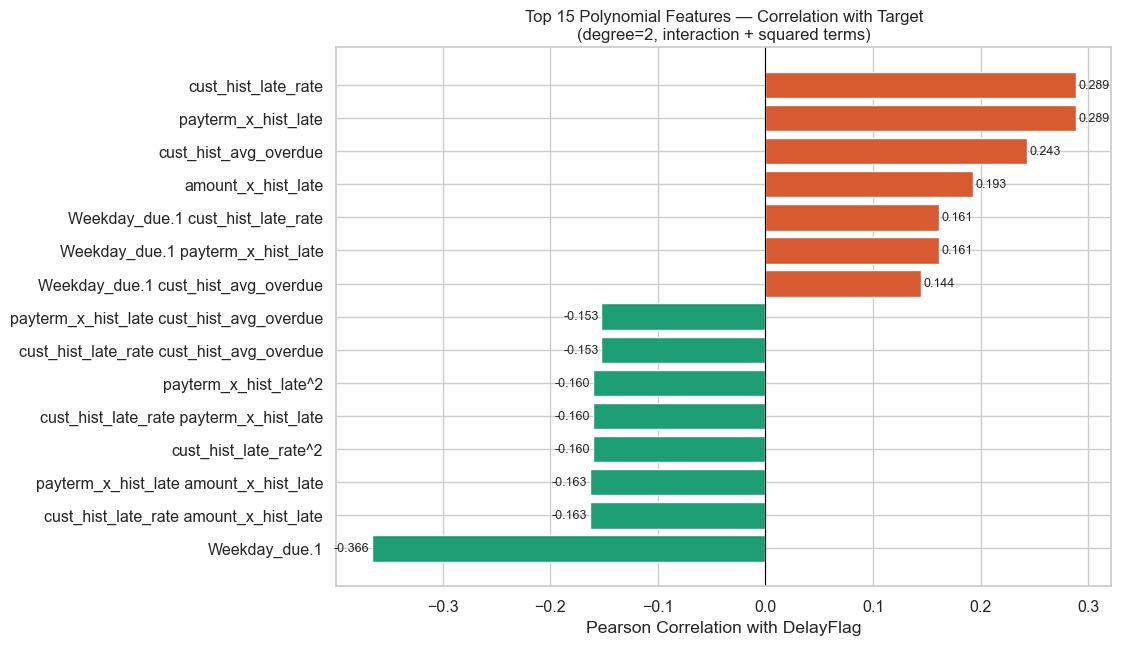

In [45]:

section("POLYNOMIAL FEATURE ENGINEERING", 7)

# Use top features by absolute correlation for polynomial expansion
top_corr = all_corr.abs().sort_values(ascending=False).head(5)
TOP_FEATS = top_corr.index.tolist()
print(f"Top 5 features for polynomial expansion:\n  {TOP_FEATS}")
print(f"  Correlation magnitudes:\n{top_corr.round(3).to_string()}")

X_top = X[TOP_FEATS]

# Scale first (important before polynomial)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_top)

# Degree-2 polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_scaled)
poly_names = poly.get_feature_names_out(TOP_FEATS)

print(f"\nOriginal feature count : {X_top.shape[1]}")
print(f"After degree-2 poly    : {X_poly.shape[1]}")
print(f"\nAll polynomial feature names:")
for i, name in enumerate(poly_names, 1):
    print(f"  {i:3d}. {name}")

X_poly_df = pd.DataFrame(X_poly, columns=poly_names)

# Correlation of polynomial features with target
poly_corr = X_poly_df.corrwith(y.reset_index(drop=True)).sort_values()

print(f"\nTop 10 polynomial features by correlation with DelayFlag:")
print(poly_corr.abs().sort_values(ascending=False).head(10).round(3).to_string())

# ─────────────────────────────────────────────────────────────
# PLOT 20 — Polynomial feature correlations
# ─────────────────────────────────────────────────────────────
top_poly = poly_corr.abs().sort_values(ascending=False).head(15)
top_poly_signed = poly_corr[top_poly.index].sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_poly = [C["coral"] if v > 0 else C["teal"] for v in top_poly_signed.values]
bars = ax.barh(top_poly_signed.index, top_poly_signed.values,
               color=colors_poly, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with DelayFlag")
ax.set_title("Top 15 Polynomial Features — Correlation with Target\n"
             "(degree=2, interaction + squared terms)", fontsize=12)

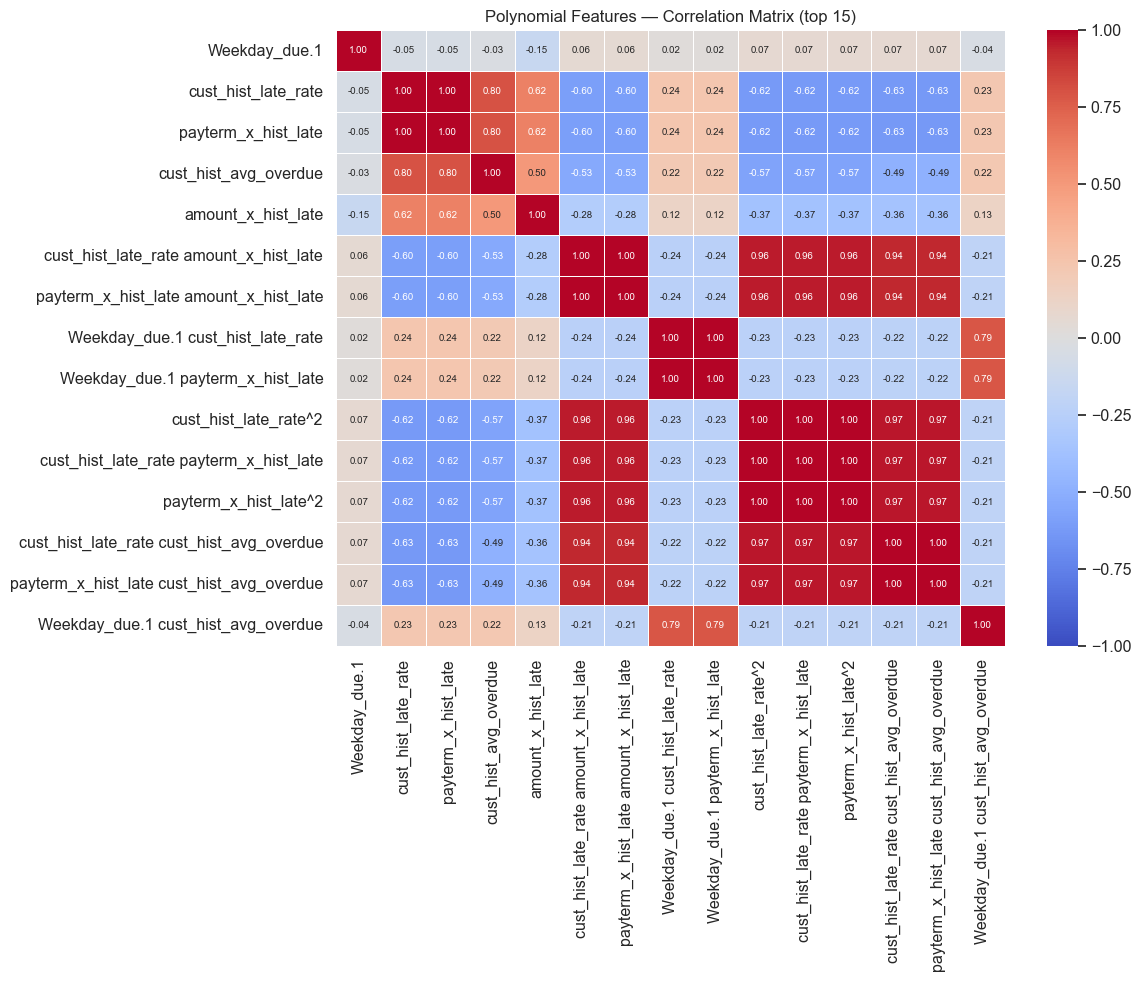

In [46]:
# PLOT 21 — Polynomial feature heatmap (correlation matrix)
# ─────────────────────────────────────────────────────────────
top15_names  = top_poly.index.tolist()
poly_corr_mat = X_poly_df[top15_names].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(poly_corr_mat, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.4, vmin=-1, vmax=1,
            annot_kws={"size": 7})
ax.set_title("Polynomial Features — Correlation Matrix (top 15)", fontsize=12)
plt.tight_layout()


# SECTION 8: DECISION BOUNDARY VISUALISATION


════════════════════════════════════════════════════════════
  SECTION 8: DECISION BOUNDARY VISUALISATION
════════════════════════════════════════════════════════════
Using top-2 features for decision boundary: ['Weekday_due.1', 'cust_hist_late_rate']


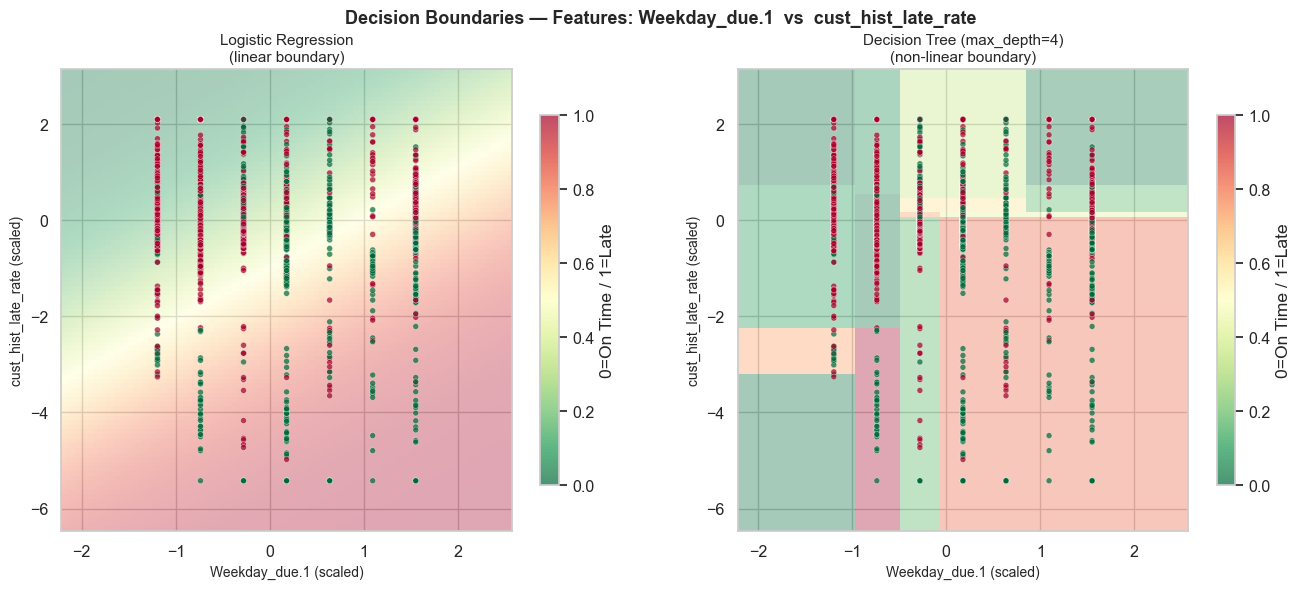

In [47]:

section("DECISION BOUNDARY VISUALISATION", 8)

# Use 2 best-correlated features for 2D boundary plots
top2 = all_corr.abs().sort_values(ascending=False).head(2).index.tolist()
print(f"Using top-2 features for decision boundary: {top2}")

X2 = scaler.fit_transform(X[top2])
y2 = y.values

sample_n = min(5000, len(X2))
idx      = np.random.RandomState(42).choice(len(X2), sample_n, replace=False)
X2s, y2s = X2[idx], y2[idx]

# ── 8.1 Logistic Regression boundary ────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X2s, y2s)

# ── 8.2 Decision Tree boundary ─────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X2s, y2s)

# ─────────────────────────────────────────────────────────────
# PLOT 22 — Decision Boundaries side by side
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Decision Boundaries — Features: {top2[0]}  vs  {top2[1]}",
             fontsize=13, fontweight="bold")

for ax, clf, title in zip(axes,
                           [lr,     dt],
                           ["Logistic Regression\n(linear boundary)",
                            "Decision Tree (max_depth=4)\n(non-linear boundary)"]):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf, X2s, ax=ax, alpha=0.35,
        cmap=plt.cm.RdYlGn,
        response_method="predict_proba" if hasattr(clf, "predict_proba") else "predict",
        plot_method="pcolormesh"
    )
    sc = ax.scatter(X2s[:, 0], X2s[:, 1], c=y2s,
                    cmap=plt.cm.RdYlGn_r, edgecolors="white",
                    linewidths=0.3, s=18, alpha=0.7,
                    vmin=0, vmax=1)
    ax.set_xlabel(f"{top2[0]} (scaled)", fontsize=10)
    ax.set_ylabel(f"{top2[1]} (scaled)", fontsize=10)
    ax.set_title(title, fontsize=11)
    plt.colorbar(sc, ax=ax, label="0=On Time / 1=Late", shrink=0.8)

## PLOT 23 — Decision Tree structure

Text(0.5, 1.0, 'Decision Tree Structure (max_depth=4, top-5 features)')

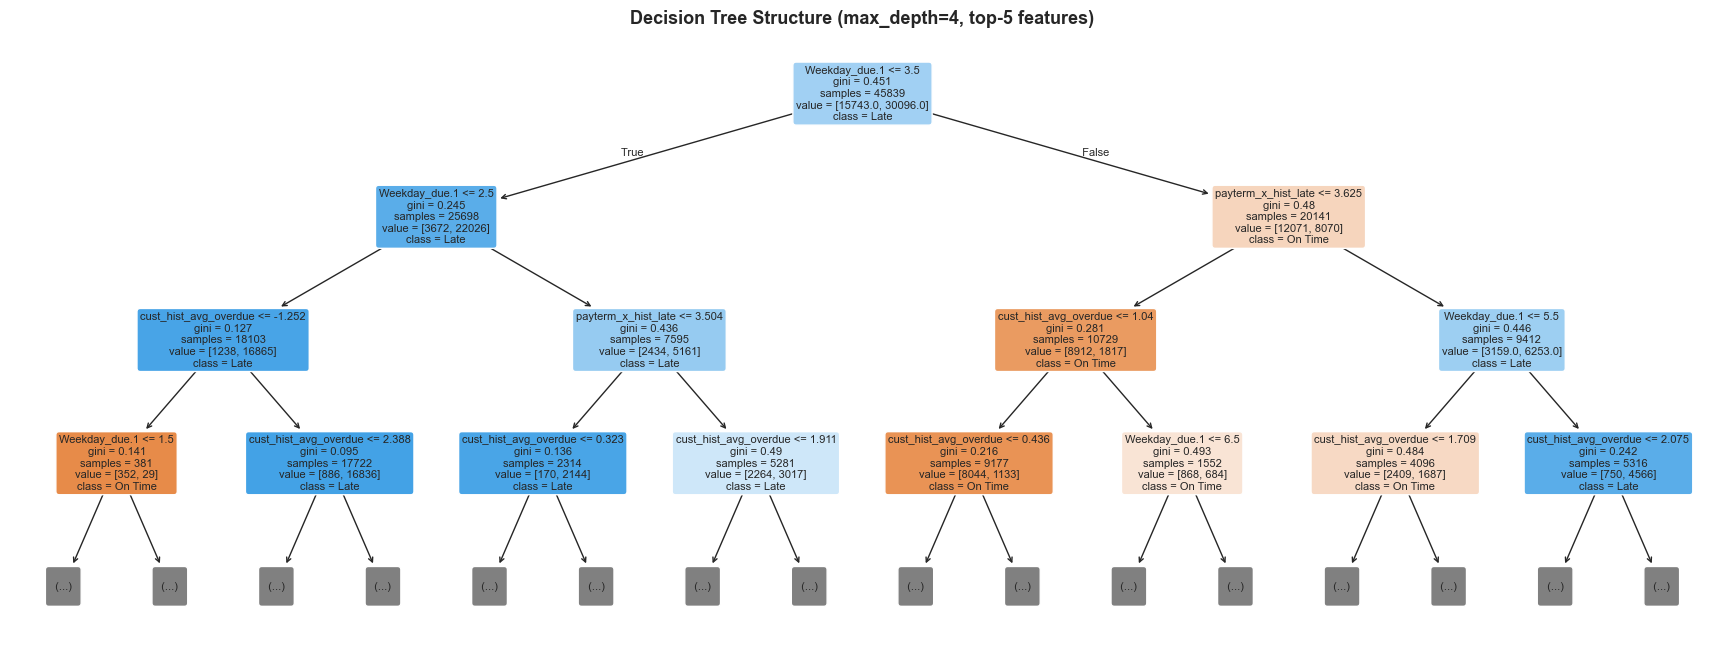

In [48]:

dt_full = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_full.fit(X[TOP_FEATS].fillna(0), y)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_full, feature_names=TOP_FEATS,
          class_names=["On Time","Late"],
          filled=True, rounded=True, fontsize=8,
          impurity=True, proportion=False, ax=ax,
          max_depth=3)
ax.set_title("Decision Tree Structure (max_depth=4, top-5 features)",
             fontsize=13, fontweight="bold")

## PLOT 24 — PCA 2D scatter of engineered features

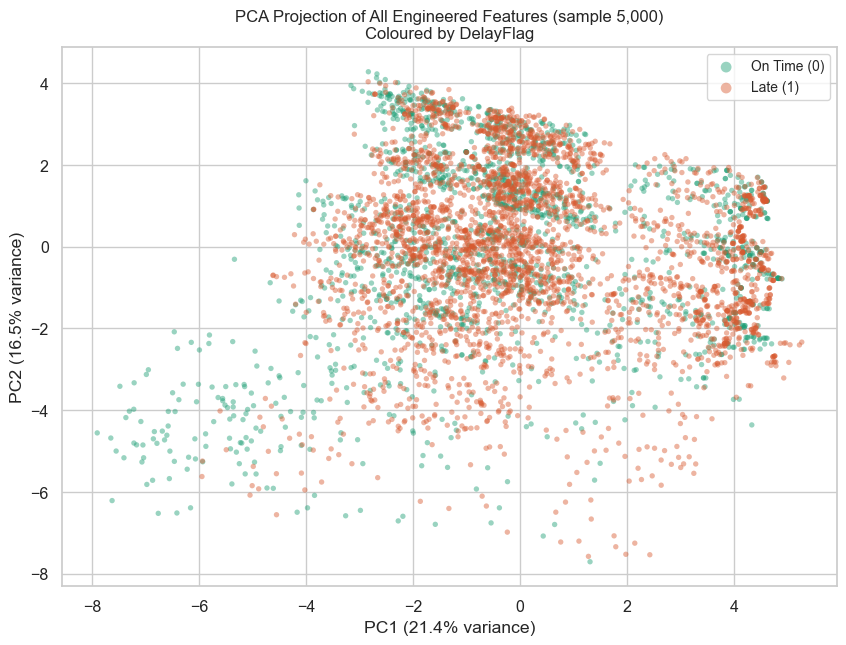

In [49]:

X_full_scaled = StandardScaler().fit_transform(X.fillna(0))
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_full_scaled)

sample_pca = np.random.RandomState(42).choice(len(X_pca2), min(5000, len(X_pca2)), replace=False)
pca_df = pd.DataFrame({
    "PC1": X_pca2[sample_pca, 0],
    "PC2": X_pca2[sample_pca, 1],
    "DelayFlag": y.values[sample_pca]
})

fig, ax = plt.subplots(figsize=(10, 7))
for flag, color, label in [(0, C["teal"], "On Time (0)"), (1, C["coral"], "Late (1)")]:
    mask = pca_df["DelayFlag"] == flag
    ax.scatter(pca_df.loc[mask,"PC1"], pca_df.loc[mask,"PC2"],
               c=color, label=label, s=15, alpha=0.45, edgecolors="none")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Projection of All Engineered Features (sample 5,000)\nColoured by DelayFlag",
             fontsize=12)
ax.legend(fontsize=10, markerscale=2)

## PLOT 25 — Feature importance from Decision Tree

Text(0.5, 1.0, 'Decision Tree Feature Importance\n(top-5 features, max_depth=4)')

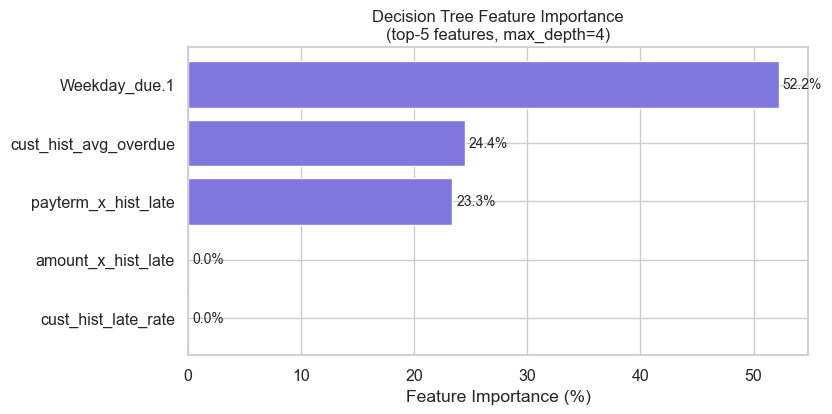

In [50]:
importances = pd.Series(dt_full.feature_importances_, index=TOP_FEATS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importances.index, importances.values * 100,
               color=C["purple"], edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
ax.set_xlabel("Feature Importance (%)")
ax.set_title("Decision Tree Feature Importance\n(top-5 features, max_depth=4)", fontsize=12)

# Final Summary

In [53]:

section("SUMMARY", 9)

print(f"""
Dataset          : {len(df_raw):,} rows → {len(df_fe):,} after cleaning
Features built   : {len(ML_FEATURES)} features (original + engineered)
Polynomial feats : {X_poly.shape[1]} (degree-2 from top-5 features)
Target (y)       : DelayFlag  [0=On Time, 1=Late]
Late rate        : {y.mean():.2%} """)


════════════════════════════════════════════════════════════
  SECTION 9: SUMMARY
════════════════════════════════════════════════════════════

Dataset          : 45,839 rows → 45,839 after cleaning
Features built   : 30 features (original + engineered)
Polynomial feats : 20 (degree-2 from top-5 features)
Target (y)       : DelayFlag  [0=On Time, 1=Late]
Late rate        : 65.66% 


In [54]:
# Save final feature-engineered data for Member 2
df_fe.to_csv("C:\\Users\\Shipra\\OneDrive\\Documents\\GitHub\\B2B-Invoice-payment-behaviour-segmentation-late-payment-predictor\\project3\\artifacts\\invoices_clean.csv", index=False)
import joblib
joblib.dump(ML_FEATURES, "artifacts/feature_names.pkl")
print("Saved: artifacts/invoices_clean.csv")
print("Saved: artifacts/feature_names.pkl")

Saved: artifacts/invoices_clean.csv
Saved: artifacts/feature_names.pkl
